# 2026-10-04 Numerical predictions of the simple gas-fading and BPT model

This notebook follows the simplified report
[20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages](../MAUVE/20261003%20The%20Origin%20of%20Fading%20Emission%20Lines%20and%20Increasing%20BPT%20Line%20Ratios%20along%20Infall%20Stages.md).
That report is the model source for this notebook. We evaluate its constant-coefficient,
HI-only stripping model, its atomic leading/reference/trailing perturbation, and its
two-component **young (compact HII + leaked OB) + HOLMES** line budget. All figures use
`plt.show()` and are embedded in the notebook; no figure files are written.

## Adopted values and assumptions

| Quantity | Value or rule used here | Status and meaning |
| --- | --- | --- |
| Molecular depletion time $\tau_{\rm dep}$ | 2 Gyr | Assumed constant; total SFR, before recycling |
| Prompt mass return $R$ | 0.4 | Assumed constant |
| Feedback loading $\eta$ | 0 | Simple baseline without a feedback outflow |
| HI stripping coefficient $\gamma_{\rm strip}$ | 3 Gyr$^{-1}$ | Assumed; no direct H$_2$ stripping |
| Reference initial HI column $\Sigma_{{\rm HI},0}$ | 10 $M_\odot\,\mathrm{pc}^{-2}$ | Illustrative local atomic column; not measured from these optical maps |
| Atomic factors $c_{\rm HI}$ | trailing 0.5; reference 1; leading 1.5 | Assumed initial conditions; common initial H$_2$ and common coefficients |
| Temporal initial-condition examples | Initial H$_2$ = 2.0 or 0.4 times the data-normalized baseline; initial HI and all coefficients fixed; no spatial perturbation | Assumed illustrative starting columns. These select declining or initially rising **reference histories**, independently of the leading/trailing comparison |
| Model H$\alpha$ calibration $C_\alpha$ | $4.98\times10^{-42}$ $M_\odot\,\mathrm{yr}^{-1}/(\mathrm{erg\,s}^{-1})$ | Report equation (31), Chabrier IMF; actual data conversion uses each FITS header's `SFRCOEF` |
| HOLMES ionizing yield $q_{\rm H,HOLMES}$ | $7\times10^{40}$ s$^{-1}M_\odot^{-1}$ | Report equation (32), adopted from Belfiore et al. (2022) |
| H$\alpha$ energy yield $\epsilon_\alpha$ | $1.3721\times10^{-12}$ erg per absorbed ionizing photon | Report equation (33), Case B |
| Old stellar fraction $f_{\rm old}$ | 1 | Explicit upper-normalization assumption: $\Sigma_*^{\rm old}=f_{\rm old}\Sigma_*$; total mass is measured, age-separated old mass is not |
| Absorbed HOLMES photon fraction | 1 | Implicit full-absorption assumption of the simple report; absorbing gas and old mass remain |
| Both intrinsic Balmer decrements | H$\alpha$/H$\beta$ = 2.86 | Common H$\alpha$ and H$\beta$ mixing weight, report equation (37) |
| HOLMES intrinsic linear ratios | N2 = 0.8; S2 = 0.8; O3 = 2.0 | Illustrative constant spectral templates, **not** measured HOLMES-only ratios or a photoionization calculation |
| Reference initial total H$\alpha$ and stellar column | Recomputed from **live pre-peak SF maps**, with equal product/galaxy weight | Runtime values and exact input provenance are printed below |
| Initial H$_2$ column | $\Sigma_{{\rm H_2},0}=\tau_{\rm dep}\Sigma_{{\rm SFR},0}$, after subtracting the assumed HOLMES H$\alpha$ floor | Model-derived from the measured H$\alpha$ scale; not a CO measurement |
| Conversion time $\tau_{\rm conv}$ | $\Sigma_{{\rm HI},0}/(\gamma_{\rm H_2}\Sigma_{{\rm H_2},0})$ | Derived by requiring initial supply-consumption balance in the reference position |
| Young intrinsic ratios | Solved from the observed pre-peak SF ratios and the assumed initial HOLMES weight | Initial normalization only; constant afterwards |
| Time grid | 0--2 Gyr, 1001 samples; checkpoints at 0.5, 1.0, 1.5, and 2.0 Gyr | Illustrative elapsed time since imposed conditions; **no times assigned to observed infall stages** |

N2 = [N II]6583/H$\alpha$; S2 = ([S II]6716 + [S II]6731)/H$\alpha$;
O3 = [O III]5007/H$\beta$. Mixing is performed in **linear** ratios and luminosities.
The assumed ordering of the intrinsic ratios is part of this simple model.

For the observational scale we use one fixed stellar-density interval,
$8.5\leq\log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])<8.75$.
We use the existing project's inclination cut $i<80^\circ$, retained stellar-fit
`SNR_POSTFIT > 25`, and six-line common detection support. SF requires finite HII SFR,
EW(H$\alpha$) $>6$ Angstrom, and intrinsic H$\alpha$ dispersion $<45$ km s$^{-1}$.
NSF is Balmer-detected usable emission outside SF; it is **not a HOLMES-only label**.
At least 50 usable pixels and 20 common six-line pixels per product/category are required.
Pre-peak SF provides a field-like **working reference**, while those objects remain Virgo members.
The data points below are descriptive comparisons within this mass interval, not a fit
of an evolutionary track to the stages.

In [1]:
from pathlib import Path
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display, Markdown

PROJECT_ROOT = Path('/Users/Igniz/Desktop/ICRAR/further')
DATA_ROOT = PROJECT_ROOT / 'v3tk_v7.6.8'
CATALOG_PATH = PROJECT_ROOT / 'mauve_master_wiki_newclass.fits'
GEOMETRY_PATH = PROJECT_ROOT / 'MAUVE_effective_radii.csv'
REPORT_PATH = PROJECT_ROOT.parent / 'MAUVE' / (
    '20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages.md')
MASK_SOURCE = PROJECT_ROOT / '20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb'
PIPELINE_PATH = PROJECT_ROOT / 'SFR+Z.py'
MASS_RANGE = (8.5, 8.75)
MIN_USABLE = 50
MIN_COMMON = 20
SNR_MIN = 25.0
EW_MIN = 6.0
SIGMA_MAX = 45.0
INCLINATION_MAX = 80.0
WCS_TOLERANCE = 0.05  # arcsec at corners and centre
TAU_DEP = 2.0        # Gyr
RETURN_FRACTION = 0.4
ETA = 0.0
GAMMA_STRIP = 3.0    # Gyr^-1; HI only
SIGMA_HI_0 = 10.0    # Msun pc^-2
C_ALPHA = 4.98e-42
Q_H_HOLMES = 7.0e40
EPSILON_ALPHA = 1.3721e-12
F_OLD = 1.0
BALMER_DECREMENT = 2.86
HOLMES_RATIOS = {'N2': 0.8, 'S2': 0.8, 'O3': 2.0}
ATOMIC_FACTORS = {'trailing': 0.5, 'reference': 1.0, 'leading': 1.5}
TIME_GYR = np.linspace(0.0, 2.0, 1001)
CHECKPOINT_TIMES = np.array([0.5, 1.0, 1.5, 2.0])
CHECKPOINT_MARKERS = ('o', 's', '^', 'D')
STAGES = ('pre-peak', 'close-to-peak', 'post-peak')
STAGE_COLORS = {'pre-peak': '#2166ac', 'close-to-peak': '#1a9850', 'post-peak': '#d73027'}
MODEL_COLORS = {'trailing': '#2166ac', 'reference': '#111111', 'leading': '#e69f00'}
LINE_COLORS = {'Halpha': '#111111', 'Hbeta': '#777777', 'NII': '#b2182b', 'SII': '#1b7837', 'OIII': '#762a83'}
LINES = ('HA6562', 'HB4861', 'NII6583', 'SII6716', 'SII6730', 'OIII5006')
mpl.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': False})
INPUT_PROVENANCE = []

def mark_time_checkpoints(ax, values, color):
    """Dots identify the four common time samples on an elapsed-time curve."""
    return ax.scatter(CHECKPOINT_TIMES, np.interp(CHECKPOINT_TIMES, TIME_GYR, values),
                      color=color, s=23, zorder=4)

def format_time_axis(ax):
    ax.set_xlim(0.0, 2.0)
    ax.set_xticks(np.r_[0.0, CHECKPOINT_TIMES])


def fingerprint(path, hdus=''):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b''):
            digest.update(block)
    INPUT_PROVENANCE.append({'path': str(path), 'bytes': path.stat().st_size,
                             'sha256': digest.hexdigest(), 'HDUs': hdus})

for path in (REPORT_PATH, CATALOG_PATH, GEOMETRY_PATH, MASK_SOURCE, PIPELINE_PATH):
    fingerprint(path)
print('Model source:', REPORT_PATH)
print('Live product root:', DATA_ROOT)
print('Python:', platform.python_version(), '| NumPy:', np.__version__, '| Matplotlib:', mpl.__version__)

Model source: /Users/Igniz/Desktop/ICRAR/MAUVE/20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages.md
Live product root: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Python: 3.13.3 | NumPy: 2.2.6 | Matplotlib: 3.10.3


## Read the actual MAUVE products

The loader below implements the relevant selection and geometry from the September 30
emission-line notebook (zero-based cells 2, 4, 6, 8, and 10), without executing that
notebook or reading any of its stored outputs. The master FITS catalogue and geometry
CSV supply stage membership and combined-product routing. `NGC4567_8` remains one product
and contributes one weight. Products failing the explicitly displayed checks are excluded.

All six raw lines must meet the product header's `CUT_SN` and `NOISE` detection thresholds;
the ratios then use **corrected** fluxes on that common support. The luminosity per adopted
area is recovered from the actual all-emission H$\alpha$-equivalent SFR map:

$$\mathcal L_\alpha^{\rm observed}
=10^{\mathrm{LOGSFR\_SURFACE\_DENSITY}}/\mathrm{SFRCOEF},\qquad
\mathcal L_\ell^{\rm observed}
=\mathcal L_\alpha^{\rm observed}F_{\ell,\rm corr}/F_{\alpha,\rm corr}.$$

For NSF, that map is a luminosity conversion, not a claim that the emission is powered
by star formation. The existing inclination corrections are already in the surface-density
maps; we apply no additional correction. Stellar and line means use exactly the same pixels.
Within each stage/category, we average each product's **linear mean surface luminosity**
equally, then form the ratio of those means. Galaxy-to-galaxy percentile ranges shown below
are descriptive scatter, not spaxel-based errors or confidence intervals.

For the NSF audit we additionally read the actual `NII_BPT` and `SII_BPT` class maps,
EW, intrinsic dispersion, and HII-SFR availability on **the same six-line support**.
The original category masks and stage estimators remain unchanged. The first failed
SF gate is bookkeeping, not a unique physical explanation for a region's emission.


In [2]:
def central_hii_masks(n2, s2, o3):
    """Central corrected-ratio cuts, matching SFR+Z.py apply_bpt_masks."""
    x_n2, x_s2, y = np.log10(n2), np.log10(s2), np.log10(o3)
    with np.errstate(divide='ignore', invalid='ignore'):
        n2_hii = (x_n2 < 0.05) & (y < 0.61/(x_n2-0.05)+1.30)
        n2_hii &= y < 0.61/(x_n2-0.47)+1.19
        s2_hii = (x_s2 < 0.32) & (y < 0.72/(x_s2-0.32)+1.30)
    return n2_hii, s2_hii

NSF_GATE_LABELS = (
    'HII SFR unavailable; stable non-HII in at least one BPT plane',
    'HII SFR unavailable; no stable non-HII and not both stable HII',
    'HII SFR unavailable despite both stable HII',
    'HII SFR available; EW missing',
    'HII SFR available; EW <= 6 Angstrom',
    'HII SFR and EW pass; intrinsic dispersion missing',
    'HII SFR and EW pass; intrinsic dispersion >= 45 km/s',
)
NSF_CENTRAL_LABELS = ('central N2 HII-like', 'central S2 HII-like',
                      'central HII-like in both planes', 'stored stable HII in both planes')

def normalise_stage(value):
    return {1: 'pre-peak', 2: 'close-to-peak', 3: 'post-peak'}[int(value)]

def first_product(folder, names):
    for name in names:
        for path in (folder / name, folder / (name + '.gz')):
            if path.is_file():
                return path
    raise FileNotFoundError(f'{folder}: none of {names}')

def read_map(path, name):
    with fits.open(path, memmap=True) as hdul:
        return np.asarray(hdul[name].data, dtype=float).copy(), hdul[name].header.copy()

def require_shape(shape, arrays):
    for name, array in arrays.items():
        if array.shape != shape:
            raise ValueError(f'{name}: {array.shape} differs from {shape}; no silent trimming')

def wcs_separation(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        raise ValueError('Missing celestial WCS')
    ny, nx = shape
    x = np.array([0, nx-1, 0, nx-1, (nx-1)/2])
    y = np.array([0, 0, ny-1, ny-1, (ny-1)/2])
    ra, dec = wa.pixel_to_world_values(x, y)
    rb, db = wb.pixel_to_world_values(x, y)
    return float(np.max(np.hypot((ra-rb)*np.cos(np.deg2rad((dec+db)/2)), dec-db))*3600)

def radius_from_geometry(shape, header, components):
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = WCS(header).celestial.pixel_to_world_values(xx, yy)
    ra, dec = np.deg2rad(ra), np.deg2rad(dec)
    radius = np.full(shape, np.inf)
    for row in components.itertuples(index=False):
        ra0, dec0 = np.deg2rad(row.center_ra_deg), np.deg2rad(row.center_dec_deg)
        dra = (ra-ra0+np.pi) % (2*np.pi)-np.pi
        cosc = np.sin(dec0)*np.sin(dec)+np.cos(dec0)*np.cos(dec)*np.cos(dra)
        east = np.cos(dec)*np.sin(dra)/cosc * 206264.806247
        north = (np.cos(dec0)*np.sin(dec)-np.sin(dec0)*np.cos(dec)*np.cos(dra))/cosc * 206264.806247
        pa = np.deg2rad(row.pa_deg_east_of_north)
        major = east*np.sin(pa)+north*np.cos(pa)
        minor = east*np.cos(pa)-north*np.sin(pa)
        radius = np.minimum(radius, np.hypot(major/row.a_re_arcsec, minor/row.b_re_arcsec))
    return radius

def measure_product(galid, stage, components):
    folder = DATA_ROOT / galid
    paths = {
        'mass': first_product(folder, [f'{galid}_spatial_binning_maps_further.fits']),
        'gas': first_product(folder, [f'{galid}_gas_bin_maps_further.fits', f'{galid}_gas_BIN_maps_further.fits']),
        'ew': first_product(folder, [f'{galid}_proxy_EW_maps_further.fits', f'{galid}_proxy_EW_maps.fits']),
        'mask': first_product(folder, [f'{galid}_mask.fits']),
        'sfh': first_product(folder, [f'{galid}_sfh_maps.fits']),
    }
    mass, mass_header = read_map(paths['mass'], 'LOGMASS_SURFACE_DENSITY')
    if mass_header.get('BUNIT') != 'log(Msol/kpc2)':
        raise ValueError('Unexpected stellar surface-density units')
    shape = mass.shape
    ew, ew_header = read_map(paths['ew'], 'PROXY_EWHA')
    snr, sfh_header = read_map(paths['sfh'], 'SNR_POSTFIT')
    with fits.open(paths['mask'], memmap=True) as hdul:
        flat_mask = np.asarray(hdul['MASKFILE'].data['MASK'], dtype=int).copy()
    if flat_mask.size != mass.size:
        raise ValueError('nGIST mask size mismatch')
    mask = flat_mask.reshape(shape)
    with fits.open(paths['gas'], memmap=True) as hdul:
        header = hdul[0].header.copy()
        gas_header = hdul['BIN_ID'].header.copy()
        names = ('BIN_ID', 'LOGSFR_SURFACE_DENSITY', 'LOGSFR_SURFACE_DENSITY_HII',
                 'HA6562_SIGMA', 'HA6562_SIGMA_CORR', 'NII_BPT', 'SII_BPT')
        arrays = {name: np.asarray(hdul[name].data, dtype=float).copy() for name in names}
        raw = {line: np.asarray(hdul[line+'_FLUX'].data, dtype=float).copy() for line in LINES}
        errors = {line: np.asarray(hdul[line+'_FLUX_ERR'].data, dtype=float).copy() for line in LINES}
        corrected = {line: np.asarray(hdul[line+'_FLUX_CORR'].data, dtype=float).copy() for line in LINES}
    require_shape(shape, {**arrays, 'EW': ew, 'SNR_POSTFIT': snr, **raw,
                          **{k+'_err': v for k,v in errors.items()}, **{k+'_corr': v for k,v in corrected.items()}})
    for other in (gas_header, ew_header, sfh_header):
        if wcs_separation(mass_header, other, shape) > WCS_TOLERANCE:
            raise ValueError('Map WCS mismatch')
    if str(header['BPTMODE']).strip().lower() != 'both':
        raise ValueError('Expected both-BPT HII selection')
    if str(header['DUSTLAW']).strip().lower() != 'calzetti':
        raise ValueError('Expected existing Calzetti correction')
    cut_sn, noise, sfrcoef = [float(header[key]) for key in ('CUT_SN', 'NOISE', 'SFRCOEF')]
    if not all(np.isfinite(v) and v > 0 for v in (cut_sn, noise, sfrcoef)):
        raise ValueError('Invalid detection/calibration header values')
    radius = radius_from_geometry(shape, mass_header, components)
    valid = np.isfinite(mass) & np.isfinite(arrays['BIN_ID']) & (mask == 0) & np.isfinite(radius)
    keep = valid & np.isfinite(snr) & (snr > SNR_MIN)
    sigma2 = arrays['HA6562_SIGMA']**2-arrays['HA6562_SIGMA_CORR']**2
    sigma_intr = np.sqrt(np.where(np.isfinite(sigma2) & (sigma2 > 0), sigma2, np.nan))
    sf = valid & np.isfinite(arrays['LOGSFR_SURFACE_DENSITY_HII']) & np.isfinite(ew) & (ew > EW_MIN)
    sf &= np.isfinite(sigma_intr) & (sigma_intr < SIGMA_MAX)
    detected = {}
    with np.errstate(divide='ignore', invalid='ignore'):
        for line in LINES:
            detected[line] = (np.isfinite(raw[line]) & np.isfinite(errors[line]) & (errors[line] > 0)
                              & (raw[line]/errors[line] >= cut_sn) & (raw[line] >= noise))
    balmer = detected['HA6562'] & detected['HB4861']
    if np.any(sf & ~balmer):
        raise ValueError('Existing SF mask includes a Balmer non-detection')
    nsf, nd = valid & balmer & ~sf, valid & ~balmer
    assert np.array_equal(sf.astype(int)+nsf.astype(int)+nd.astype(int), valid.astype(int))
    common = np.logical_and.reduce(list(detected.values()))
    common &= np.logical_and.reduce([np.isfinite(v) & (v > 0) for v in corrected.values()])
    common &= np.isfinite(arrays['LOGSFR_SURFACE_DENSITY'])
    window = (mass >= MASS_RANGE[0]) & (mass < MASS_RANGE[1])
    n_usable = int((keep & window).sum())
    records, diagnostics = [], []
    for category, category_mask in [('SF', sf), ('NSF', nsf)]:
        use = keep & window & category_mask & common
        n_common = int(use.sum())
        record = {'GALID': galid, 'stage': stage, 'category': category,
                  'N_usable': n_usable, 'N_common': n_common,
                  'eligible': n_usable >= MIN_USABLE and n_common >= MIN_COMMON}
        if n_common:
            lha = np.power(10.0, arrays['LOGSFR_SURFACE_DENSITY'][use])/sfrcoef
            ha_flux = corrected['HA6562'][use]
            line = {k: lha*corrected[k][use]/ha_flux for k in LINES}
            record.update(sigma_star=float(np.mean(10.0**mass[use])),
                          Halpha=float(lha.mean()), Hbeta=float(line['HB4861'].mean()),
                          NII=float(line['NII6583'].mean()), OIII=float(line['OIII5006'].mean()),
                          SII=float((line['SII6716']+line['SII6730']).mean()))
        records.append(record)
        if category == 'NSF' and n_common:
            nii_class, sii_class = arrays['NII_BPT'][use], arrays['SII_BPT'][use]
            if not (np.isin(nii_class, [-1, 0, 1, 2, 3]).all()
                    and np.isin(sii_class, [-1, 0, 1, 2, 3]).all()):
                raise ValueError('Unexpected BPT class codes')
            available = np.isfinite(arrays['LOGSFR_SURFACE_DENSITY_HII'][use])
            stable_non_hii = np.isin(nii_class, [2, 3]) | np.isin(sii_class, [2, 3])
            stable_both_hii = (nii_class == 1) & (sii_class == 1)
            local_ew, local_sigma = ew[use], sigma_intr[use]
            conditions = (~available & stable_non_hii,
                          ~available & ~stable_both_hii,
                          ~available,
                          ~np.isfinite(local_ew), local_ew <= EW_MIN,
                          ~np.isfinite(local_sigma), local_sigma >= SIGMA_MAX)
            remainder = np.ones(n_common, dtype=bool)
            gate_masks = {}
            for label, condition in zip(NSF_GATE_LABELS, conditions):
                gate_masks[label] = remainder & condition
                remainder &= ~condition
            if remainder.any():
                raise ValueError('Unexplained NSF pixels after first-failed-gate decomposition')
            assert np.all(np.sum(list(gate_masks.values()), axis=0) == 1)
            n2_hii, s2_hii = central_hii_masks(
                corrected['NII6583'][use]/ha_flux,
                (corrected['SII6716'][use]+corrected['SII6730'][use])/ha_flux,
                corrected['OIII5006'][use]/corrected['HB4861'][use])
            central_masks = dict(zip(NSF_CENTRAL_LABELS,
                                     (n2_hii, s2_hii, n2_hii & s2_hii, stable_both_hii)))
            for kind, selections in [('first failed SF gate', gate_masks),
                                      ('BPT location/class', central_masks)]:
                for label, selection in selections.items():
                    diagnostics.append({
                        'GALID': galid, 'stage': stage, 'eligible': record['eligible'],
                        'kind': kind, 'selection': label, 'N_NSF_common': n_common,
                        'N_selected': int(selection.sum()), 'pixel_fraction': float(selection.mean()),
                        # Divide by all NSF pixels, so summed gate contributions recover its mean.
                        'Halpha_contribution': float(lha[selection].sum()/n_common),
                        'Halpha_total': record['Halpha']})
    # Fingerprints are computed from the files actually opened, not cached summaries.
    hdu_lists = {'mass': 'LOGMASS_SURFACE_DENSITY', 'gas': ', '.join(names)+', six raw/error/corrected lines',
                 'ew': 'PROXY_EWHA', 'mask': 'MASKFILE.MASK', 'sfh': 'SNR_POSTFIT'}
    for key, path in paths.items():
        fingerprint(path, hdu_lists[key])
    provenance = {'GALID': galid, **{key: header.get(key) for key in
                  ('CUT_SN', 'NOISE', 'SFRCOEF', 'DIST_MPC', 'SFRIMF', 'DUSTLAW', 'BPTMODE')}}
    return records, provenance, diagnostics

In [3]:
with fits.open(CATALOG_PATH, memmap=True) as hdul:
    master = pd.DataFrame({'galaxy': [str(s).strip() for s in hdul[1].data['Galaxy']],
                           'stage': [normalise_stage(v) for v in hdul[1].data['class']]})
geometry = pd.read_csv(GEOMETRY_PATH).merge(master, on='galaxy', how='left', validate='one_to_one')
if not geometry['stage'].eq(geometry.mauve_infall_stage.map(normalise_stage)).all():
    raise ValueError('Master/geometry stage disagreement')
qc, measured, header_rows, diagnostic_rows = [], [], [], []
for galid, components in geometry.groupby('notebook_product_id', sort=True):
    if components.stage.nunique() != 1:
        raise ValueError(f'{galid}: inconsistent component stages')
    stage, inclination = components.stage.iloc[0], float(components.inclination_deg.max())
    status = 'excluded: inclination >= 80 deg'
    if inclination < INCLINATION_MAX:
        try:
            rows, provenance, diagnostics = measure_product(galid, stage, components)
            measured.extend(rows)
            diagnostic_rows.extend(diagnostics)
            header_rows.append(provenance)
            status = 'OK'
        except (FileNotFoundError, KeyError, ValueError, OSError) as exc:
            status = f'excluded: {type(exc).__name__}: {exc}'
    qc.append({'GALID': galid, 'stage': stage, 'inclination_deg': inclination, 'status': status})
    print(f'{galid}: {status}', flush=True)

SAMPLE_QC = pd.DataFrame(qc)
OBS_BY_GALAXY = pd.DataFrame(measured)
HEADER_PROVENANCE = pd.DataFrame(header_rows)
support_rows = []
for stage in STAGES:
    for category in ('SF', 'NSF'):
        group = OBS_BY_GALAXY.loc[(OBS_BY_GALAXY.stage == stage) &
                                  (OBS_BY_GALAXY.category == category) & OBS_BY_GALAXY.eligible]
        if len(group) < 3:
            raise RuntimeError(f'{stage} {category}: fewer than three supported products; inspect QC/window')
        row = {'stage': stage, 'category': category, 'N_galaxies': len(group),
               'GALIDs': ', '.join(group.GALID)}
        for key in ('sigma_star', 'Halpha', 'Hbeta', 'NII', 'SII', 'OIII'):
            row[key] = float(group[key].mean())
        for name, numerator, denominator in [('N2','NII','Halpha'), ('S2','SII','Halpha'), ('O3','OIII','Hbeta')]:
            row[name] = row[numerator]/row[denominator]
        support_rows.append(row)
OBS_STAGE = pd.DataFrame(support_rows)
NSF_DIAGNOSTICS_BY_GALAXY = pd.DataFrame(diagnostic_rows)
print('\nLive QC, mass-window support, and calibration provenance')
display(SAMPLE_QC)
display(OBS_BY_GALAXY[['GALID','stage','category','N_usable','N_common','eligible']])
display(HEADER_PROVENANCE)
display(OBS_STAGE)
print('Input fingerprints:', len(INPUT_PROVENANCE), '| all observational scales computed in this run')

IC3392: OK
NGC4064: OK
NGC4189: OK
NGC4192: excluded: inclination >= 80 deg
NGC4216: excluded: inclination >= 80 deg
NGC4222: excluded: inclination >= 80 deg
NGC4254: OK
NGC4293: OK
NGC4294: OK
NGC4298: OK
NGC4302: excluded: inclination >= 80 deg
NGC4321: OK
NGC4330: excluded: inclination >= 80 deg
NGC4351: OK
NGC4380: OK
NGC4383: OK
NGC4388: excluded: inclination >= 80 deg
NGC4394: OK
NGC4396: excluded: inclination >= 80 deg
NGC4402: excluded: inclination >= 80 deg
NGC4405: OK
NGC4419: OK
NGC4424: OK
NGC4450: OK
NGC4457: OK
NGC4501: OK
NGC4522: excluded: inclination >= 80 deg
NGC4535: OK
NGC4548: excluded: FileNotFoundError: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4548: none of ['NGC4548_spatial_binning_maps_further.fits']
NGC4567_8: OK
NGC4569: OK
NGC4579: excluded: FileNotFoundError: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4579: none of ['NGC4579_spatial_binning_maps_further.fits']
NGC4580: OK
NGC4606: OK
NGC4607: excluded: inclination >= 80 deg
NGC4654: OK
NGC46

,GALID,stage,inclination_deg,status
0,IC3392,post-peak,68.0,OK
1,NGC4064,post-peak,70.0,OK
2,NGC4189,pre-peak,42.0,OK
3,NGC4192,pre-peak,83.0,excluded: inclination >= 80 deg
4,NGC4216,post-peak,90.0,excluded: inclination >= 80 deg
5,NGC4222,pre-peak,90.0,excluded: inclination >= 80 deg
6,NGC4254,pre-peak,39.0,OK
7,NGC4293,post-peak,67.0,OK
8,NGC4294,pre-peak,74.0,OK
9,NGC4298,close-to-peak,52.0,OK


,GALID,stage,category,N_usable,N_common,eligible
0,IC3392,post-peak,SF,1729,1653,True
1,IC3392,post-peak,NSF,1729,62,True
2,NGC4064,post-peak,SF,6328,1371,True
3,NGC4064,post-peak,NSF,6328,4206,True
4,NGC4189,pre-peak,SF,2865,166,True
5,NGC4189,pre-peak,NSF,2865,2381,True
6,NGC4254,pre-peak,SF,36987,28638,True
7,NGC4254,pre-peak,NSF,36987,8296,True
8,NGC4293,post-peak,SF,18662,116,True
9,NGC4293,post-peak,NSF,18662,11683,True


,GALID,CUT_SN,NOISE,SFRCOEF,DIST_MPC,SFRIMF,DUSTLAW,BPTMODE
0,IC3392,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
1,NGC4064,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
2,NGC4189,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
3,NGC4254,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
4,NGC4293,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
5,NGC4294,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
6,NGC4298,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
7,NGC4321,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
8,NGC4351,3,20,4.983582e-42,16.5,Chabrier,calzetti,both
9,NGC4380,3,20,4.983582e-42,16.5,Chabrier,calzetti,both


,stage,category,N_galaxies,GALIDs,sigma_star,Halpha,Hbeta,NII,SII,OIII,N2,S2,O3
0,pre-peak,SF,7,"NGC4189, NGC4254, NGC4321, NGC4351, NGC4383, N...",3.988350e+08,1.561418e+40,5.459504e+39,3.959624e+39,3.473972e+39,3.251291e+39,0.253591,0.222488,0.595529
1,pre-peak,NSF,6,"NGC4189, NGC4254, NGC4321, NGC4383, NGC4535, N...",4.110639e+08,3.557592e+39,1.244148e+39,1.327194e+39,1.342272e+39,1.116975e+39,0.373060,0.377298,0.897783
2,close-to-peak,SF,5,"NGC4298, NGC4424, NGC4501, NGC4654, NGC4694",4.081034e+08,9.892378e+39,3.458873e+39,3.135795e+39,2.549842e+39,8.670818e+38,0.316991,0.257758,0.250683
3,close-to-peak,NSF,5,"NGC4298, NGC4424, NGC4501, NGC4654, NGC4694",4.040434e+08,2.077480e+39,7.266294e+38,9.071701e+38,8.013007e+38,3.399153e+38,0.436669,0.385708,0.467797
4,post-peak,SF,12,"IC3392, NGC4064, NGC4293, NGC4380, NGC4405, NG...",4.063783e+08,7.579700e+39,2.650245e+39,2.417060e+39,1.729012e+39,5.565278e+38,0.318886,0.228111,0.209991
5,post-peak,NSF,13,"IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NG...",4.139633e+08,1.110611e+39,3.892034e+38,6.289469e+38,4.629425e+38,2.929788e+38,0.566307,0.416836,0.752765


## Observational reference in the selected stellar-density interval

Symbols show equal-product stage means and ratios of mean line intensities.
Vertical segments span the 16th--84th percentiles of the individual product summaries;
they show scatter, with no implication that pixels are independent galaxies.
Filled circles are SF and open squares NSF. The categories are selected separately at
each stage; these points do not trace the same regions through time.

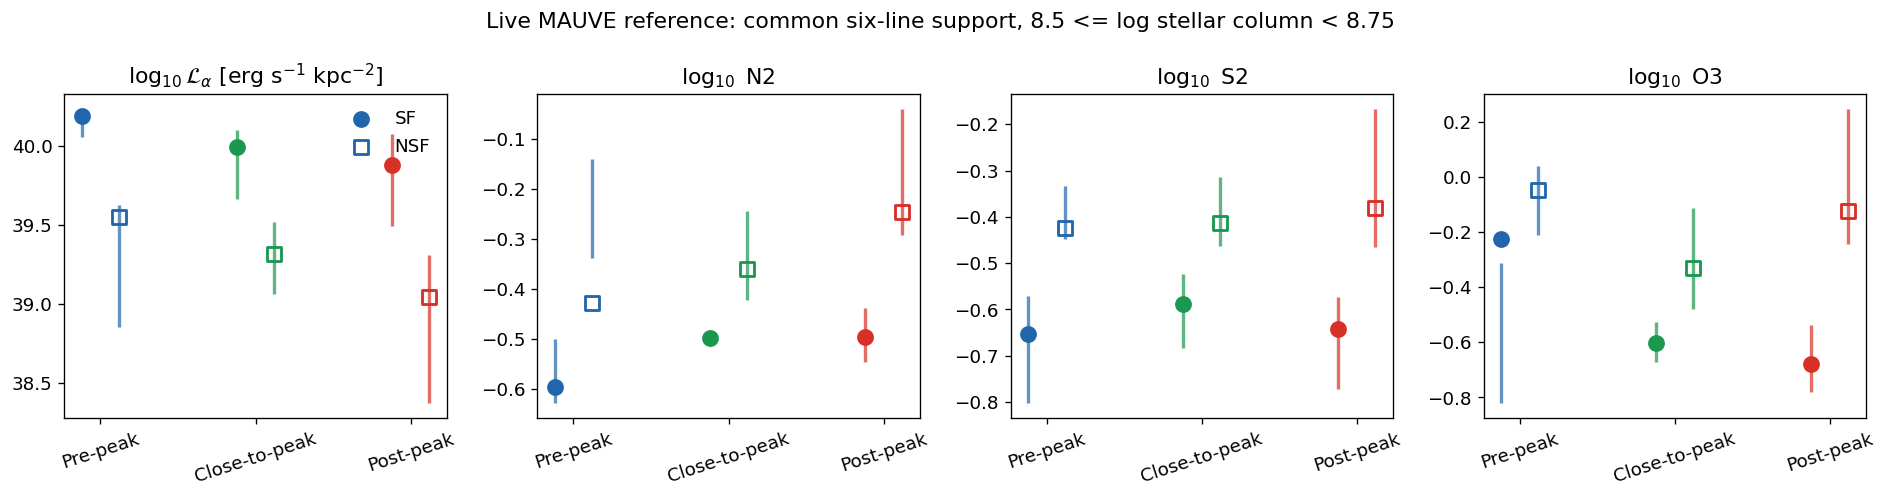

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for category, dx, marker in [('SF', -0.12, 'o'), ('NSF', 0.12, 's')]:
    for index, stage in enumerate(STAGES):
        row = OBS_STAGE.loc[(OBS_STAGE.stage == stage) & (OBS_STAGE.category == category)].iloc[0]
        group = OBS_BY_GALAXY.loc[(OBS_BY_GALAXY.stage == stage) &
                                  (OBS_BY_GALAXY.category == category) & OBS_BY_GALAXY.eligible]
        metrics = [('Halpha', group.Halpha.to_numpy()),
                   ('N2', (group.NII/group.Halpha).to_numpy()),
                   ('S2', (group.SII/group.Halpha).to_numpy()),
                   ('O3', (group.OIII/group.Hbeta).to_numpy())]
        for ax, (name, values) in zip(axes, metrics):
            lo, hi = np.percentile(np.log10(values), [16, 84])
            ax.vlines(index+dx, lo, hi, color=STAGE_COLORS[stage], lw=2, alpha=0.7)
            ax.scatter(index+dx, np.log10(row[name]), marker=marker, s=70,
                       facecolors=STAGE_COLORS[stage] if category == 'SF' else 'none',
                       edgecolors=STAGE_COLORS[stage], lw=1.7, zorder=3,
                       label=category if index == 0 else None)
for ax, title in zip(axes, [r'$\log_{10}\mathcal{L}_\alpha$ [erg s$^{-1}$ kpc$^{-2}$]',
                            r'$\log_{10}$ N2', r'$\log_{10}$ S2', r'$\log_{10}$ O3']):
    ax.set_title(title)
    ax.set_xticks(range(3), ['Pre-peak', 'Close-to-peak', 'Post-peak'], rotation=18)
axes[0].legend(frameon=False)
fig.suptitle('Live MAUVE reference: common six-line support, 8.5 <= log stellar column < 8.75')
fig.tight_layout()
plt.show()

## Normalize the reference and evaluate the explicit gas solution

Let the measured pre-peak SF total H$\alpha$ scale be $\mathcal L_{\alpha,0}^{\rm obs}$.
For our assumed old stellar fraction and full absorption,

$$\mathcal L_\alpha^{\rm HOLMES}=\epsilon_\alpha q_{\rm H,HOLMES}f_{\rm old}\Sigma_*,$$
$$\mathcal L_{\alpha,0}^{\rm young}=\mathcal L_{\alpha,0}^{\rm obs}-\mathcal L_\alpha^{\rm HOLMES},
\quad\Sigma_{{\rm SFR},0}=C_\alpha\mathcal L_{\alpha,0}^{\rm young}.$$

Subtracting the floor prevents counting the same initial H$\alpha$ twice. The observation
does not independently measure the HOLMES contribution. With the chosen $\tau_{\rm dep}$,
the initial H$_2$ column is then derived. The reference starts with balanced supply, so
$\gamma_{\rm H_2}=0.3$ Gyr$^{-1}$ and
$\tau_{\rm conv}=\Sigma_{{\rm HI},0}/(\gamma_{\rm H_2}\Sigma_{{\rm H_2},0})$.

The code below implements report equations (7), (8), (13), (14), (27), and (28).
Dots on elapsed-time curves identify 0.5, 1.0, 1.5, and 2.0 Gyr; the tables below give their values.
Time is in Gyr and gas columns in $M_\odot\,\mathrm{pc}^{-2}$; converting
gas/Gyr to $M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}$ requires a factor $10^{-3}$.

This balanced, data-normalized baseline is retained for the emission-line calculation.
The separate initial-condition examples below vary only the initial molecular column;
they do not rederive the conversion time or alter the observational normalization.


In [5]:
observed_reference = OBS_STAGE.loc[(OBS_STAGE.stage == 'pre-peak') & (OBS_STAGE.category == 'SF')].iloc[0]
SIGMA_STAR = float(observed_reference.sigma_star)  # Msun kpc^-2
L_ALPHA_OBS_0 = float(observed_reference.Halpha)   # erg s^-1 kpc^-2
L_ALPHA_HOLMES = EPSILON_ALPHA*Q_H_HOLMES*F_OLD*SIGMA_STAR
L_ALPHA_YOUNG_0 = L_ALPHA_OBS_0-L_ALPHA_HOLMES
if L_ALPHA_YOUNG_0 <= 0:
    raise ValueError('Assumed HOLMES floor exceeds observed initial Halpha; normalization is inadmissible')
SIGMA_SFR_0 = C_ALPHA*L_ALPHA_YOUNG_0
SIGMA_H2_0 = SIGMA_SFR_0*TAU_DEP*1e3
GAMMA_H2 = (1-RETURN_FRACTION+ETA)/TAU_DEP
TAU_CONV = SIGMA_HI_0/(GAMMA_H2*SIGMA_H2_0)
GAMMA_HI = 1/TAU_CONV+GAMMA_STRIP
W_HOLMES_0 = L_ALPHA_HOLMES/L_ALPHA_OBS_0
YOUNG_RATIOS = {name: (float(observed_reference[name])-W_HOLMES_0*value)/(1-W_HOLMES_0)
                for name, value in HOLMES_RATIOS.items()}
if not all(0 < YOUNG_RATIOS[k] < HOLMES_RATIOS[k] for k in HOLMES_RATIOS):
    raise ValueError('Chosen HOLMES templates violate the assumed ratio ordering; inspect live normalization')

def gas_solution(time_gyr, c_hi=1.0, gamma_strip=GAMMA_STRIP,
                 sigma_hi_0=SIGMA_HI_0, sigma_h2_0=SIGMA_H2_0):
    t = np.asarray(time_gyr, dtype=float)
    gamma_hi = 1/TAU_CONV+gamma_strip
    difference = gamma_hi-GAMMA_H2
    # Stable form of (exp(-gamma_HI*t)-exp(-gamma_H2*t))/(gamma_H2-gamma_HI).
    if np.isclose(difference, 0.0, rtol=0, atol=1e-12):
        response = t*np.exp(-GAMMA_H2*t)
    else:
        response = np.exp(-GAMMA_H2*t)*(-np.expm1(-difference*t))/difference
    hi = c_hi*sigma_hi_0*np.exp(-gamma_hi*t)
    supplied_h2 = c_hi*sigma_hi_0/TAU_CONV*response
    h2 = sigma_h2_0*np.exp(-GAMMA_H2*t)+supplied_h2
    return {'HI': hi, 'H2': h2, 'supply': hi/TAU_CONV,
            'supplied_H2': supplied_h2, 'SFR': h2/TAU_DEP*1e-3,
            'F_SFR': h2/sigma_h2_0, 'gamma_HI': gamma_hi}

reference = gas_solution(TIME_GYR)  # balanced baseline for the existing emission model
NO_RPS = gas_solution(TIME_GYR, gamma_strip=0.0)
# This comparison has the same initial columns but still has no external HI supply.
derived = pd.DataFrame([
    ('measured stellar column', SIGMA_STAR, 'Msun kpc^-2', 'live pre-peak SF, equal-product mean'),
    ('measured initial total Halpha', L_ALPHA_OBS_0, 'erg s^-1 kpc^-2', 'live pre-peak SF'),
    ('assumed HOLMES Halpha floor', L_ALPHA_HOLMES, 'erg s^-1 kpc^-2', 'report eq. 33, f_old=1 and full absorption'),
    ('initial young Halpha', L_ALPHA_YOUNG_0, 'erg s^-1 kpc^-2', 'observed total minus assumed floor'),
    ('initial HOLMES light fraction', W_HOLMES_0, 'dimensionless', 'floor / observed total'),
    ('initial true model SFR', SIGMA_SFR_0, 'Msun yr^-1 kpc^-2', 'C_alpha times initial young Halpha'),
    ('initial molecular column', SIGMA_H2_0, 'Msun pc^-2', 'derived; not measured molecular gas'),
    ('conversion time', TAU_CONV, 'Gyr', 'derived initial balance'),
    ('molecular consumption rate', GAMMA_H2, 'Gyr^-1', '(1-R+eta)/tau_dep'),
    ('atomic removal rate', GAMMA_HI, 'Gyr^-1', '1/tau_conv + gamma_strip'),
    ('initial replenishment time', 1/GAMMA_H2, 'Gyr', 'balanced reference tau_Phi,0'),
], columns=['quantity','value','unit','provenance'])
display(derived)
display(pd.DataFrame({'initial observed SF mixture': {k: float(observed_reference[k]) for k in HOLMES_RATIOS},
                      'young template (derived)': YOUNG_RATIOS,
                      'HOLMES template (assumed)': HOLMES_RATIOS}))

,quantity,value,unit,provenance
0,measured stellar column,3.988350e+08,Msun kpc^-2,"live pre-peak SF, equal-product mean"
1,measured initial total Halpha,1.561418e+40,erg s^-1 kpc^-2,live pre-peak SF
2,assumed HOLMES Halpha floor,3.830691e+37,erg s^-1 kpc^-2,"report eq. 33, f_old=1 and full absorption"
3,initial young Halpha,1.557587e+40,erg s^-1 kpc^-2,observed total minus assumed floor
4,initial HOLMES light fraction,2.453341e-03,dimensionless,floor / observed total
5,initial true model SFR,7.756786e-02,Msun yr^-1 kpc^-2,C_alpha times initial young Halpha
6,initial molecular column,1.551357e+02,Msun pc^-2,derived; not measured molecular gas
7,conversion time,2.148656e-01,Gyr,derived initial balance
8,molecular consumption rate,3.000000e-01,Gyr^-1,(1-R+eta)/tau_dep
9,atomic removal rate,7.654071e+00,Gyr^-1,1/tau_conv + gamma_strip


,initial observed SF mixture,young template (derived),HOLMES template (assumed)
N2,0.253591,0.252248,0.8
S2,0.222488,0.221068,0.8
O3,0.595529,0.592075,2.0


At 2 Gyr: reference remaining SFR = 0.5712; zero-supply bound = 0.5488


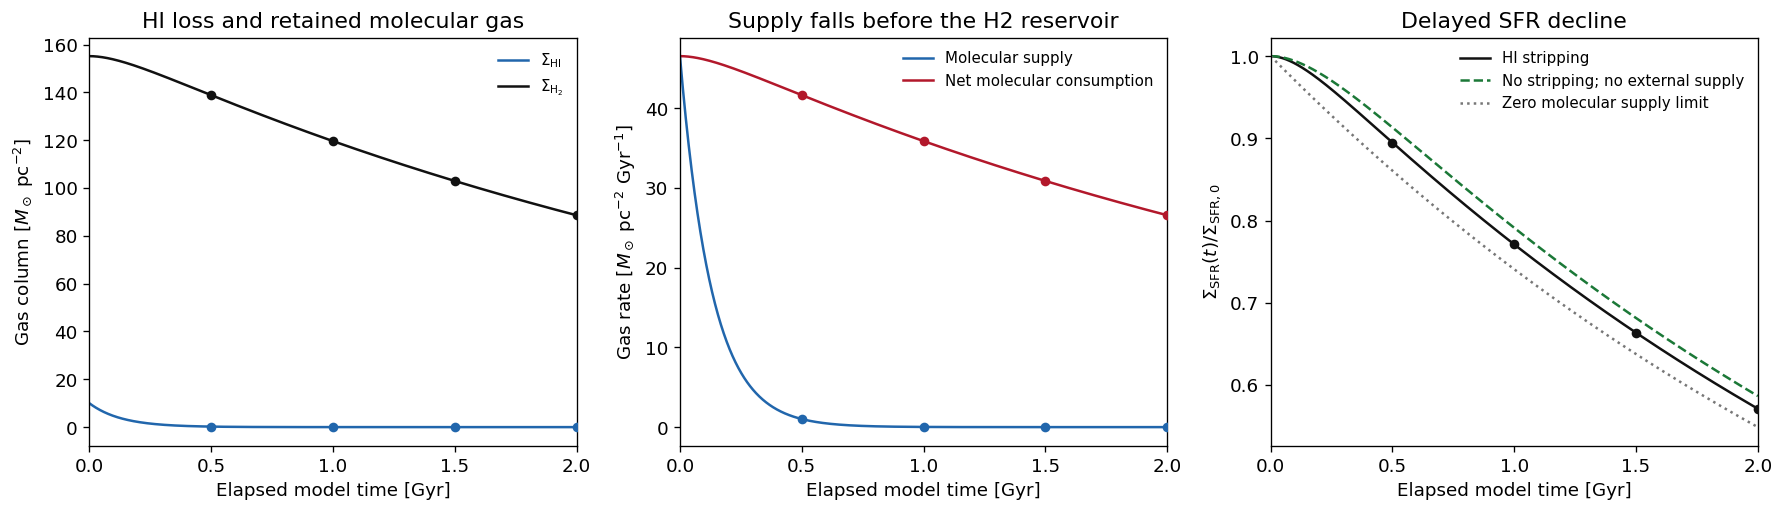

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(TIME_GYR, reference['HI'], color='#2166ac', label=r'$\Sigma_{\rm HI}$')
axes[0].plot(TIME_GYR, reference['H2'], color='#111111', label=r'$\Sigma_{\rm H_2}$')
axes[0].set_ylabel(r'Gas column [$M_\odot$ pc$^{-2}$]')
axes[0].set_title('HI loss and retained molecular gas')
axes[1].plot(TIME_GYR, reference['supply'], color='#2166ac', label='Molecular supply')
axes[1].plot(TIME_GYR, GAMMA_H2*reference['H2'], color='#b2182b', label='Net molecular consumption')
axes[1].set_ylabel(r'Gas rate [$M_\odot$ pc$^{-2}$ Gyr$^{-1}$]')
axes[1].set_title('Supply falls before the H2 reservoir')
axes[2].plot(TIME_GYR, reference['F_SFR'], color='#111111', label='HI stripping')
axes[2].plot(TIME_GYR, NO_RPS['F_SFR'], '--', color='#1b7837', label='No stripping; no external supply')
axes[2].plot(TIME_GYR, np.exp(-GAMMA_H2*TIME_GYR), ':', color='#777777', label='Zero molecular supply limit')
axes[2].set_ylabel(r'$\Sigma_{\rm SFR}(t)/\Sigma_{{\rm SFR},0}$')
axes[2].set_title('Delayed SFR decline')
for ax in axes:
    ax.set_xlabel('Elapsed model time [Gyr]')
    format_time_axis(ax)
    ax.legend(frameon=False, fontsize=9)
mark_time_checkpoints(axes[0], reference['HI'], '#2166ac')
mark_time_checkpoints(axes[0], reference['H2'], '#111111')
mark_time_checkpoints(axes[1], reference['supply'], '#2166ac')
mark_time_checkpoints(axes[1], GAMMA_H2*reference['H2'], '#b2182b')
mark_time_checkpoints(axes[2], reference['F_SFR'], '#111111')
fig.tight_layout()
plt.show()
print(f'At 2 Gyr: reference remaining SFR = {reference["F_SFR"][-1]:.4f}; '
      f'zero-supply bound = {np.exp(-GAMMA_H2*TIME_GYR[-1]):.4f}')

## Temporal response: two initial conditions, without a spatial comparison

This is the **time history at one reference position**. We set $c_{\rm HI}=1$ in both
examples and hold $\Sigma_{{\rm HI},0}$, $\tau_{\rm conv}$, $\tau_{\rm dep}$, $R$,
$\eta$, and $\gamma_{\rm strip}$ fixed. We vary only $\Sigma_{{\rm H_2},0}$:
the declining example starts with **2.0 times**, and the initially rising example with
**0.4 times**, the data-normalized baseline molecular column. These are illustrative
initial conditions, not molecular-gas measurements. The conversion time remains the
one already derived for the balanced baseline; it is not retuned to rebalance each example.

From report sections 3.3--3.4, equations (16)--(25), define the initial supply and
replenishment time by

$$\Sigma_{\Phi,0}=\frac{\Sigma_{{\rm HI},0}}{\tau_{\rm conv}},\qquad
\tau_{\Phi,0}=\frac{\Sigma_{{\rm H_2},0}}{\Sigma_{\Phi,0}}.$$

Then the temporal sign is

$$\frac{1}{\Sigma_{{\rm SFR},0}}
\left.\frac{d\Sigma_{\rm SFR}}{dt}\right|_{t=0}
=\frac{1}{\tau_{\Phi,0}}-\gamma_{\rm H_2}.$$

For $1/\tau_{\Phi,0}\leq\gamma_{\rm H_2}$, H$_2$ and SFR decrease monotonically
(the equality case starts with zero slope). For $1/\tau_{\Phi,0}>\gamma_{\rm H_2}$,
both initially rise, reach a common temporal maximum, and then decline as the HI supply fades.
With constant $\tau_{\rm dep}$, their fractional histories are identical. The reference
histories here are not called leading or trailing.

Setting $\frac{d\Sigma_{\rm H_2}}{dt}=0$ in the explicit solution gives report equation (24):

$$t_{\rm peak}=\frac{1}{\gamma_{\rm HI}-\gamma_{\rm H_2}}
\ln\!\left[\frac{\gamma_{\rm HI}}
{\gamma_{\rm H_2}\{1+(\gamma_{\rm HI}-\gamma_{\rm H_2})\tau_{\Phi,0}\}}\right].$$

The peak is positive in the initially rising case. For equal removal rates its finite
limit is $t_{\rm peak}=1/\gamma_{\rm H_2}-\tau_{\Phi,0}$. The code marks this maximum
and uses an early-time inset to resolve the rise and turnover. These temporal examples
are independent of the **spatial** offsets in the next section. The emission-line and
BPT calculations later continue to use the original balanced, data-normalized baseline.


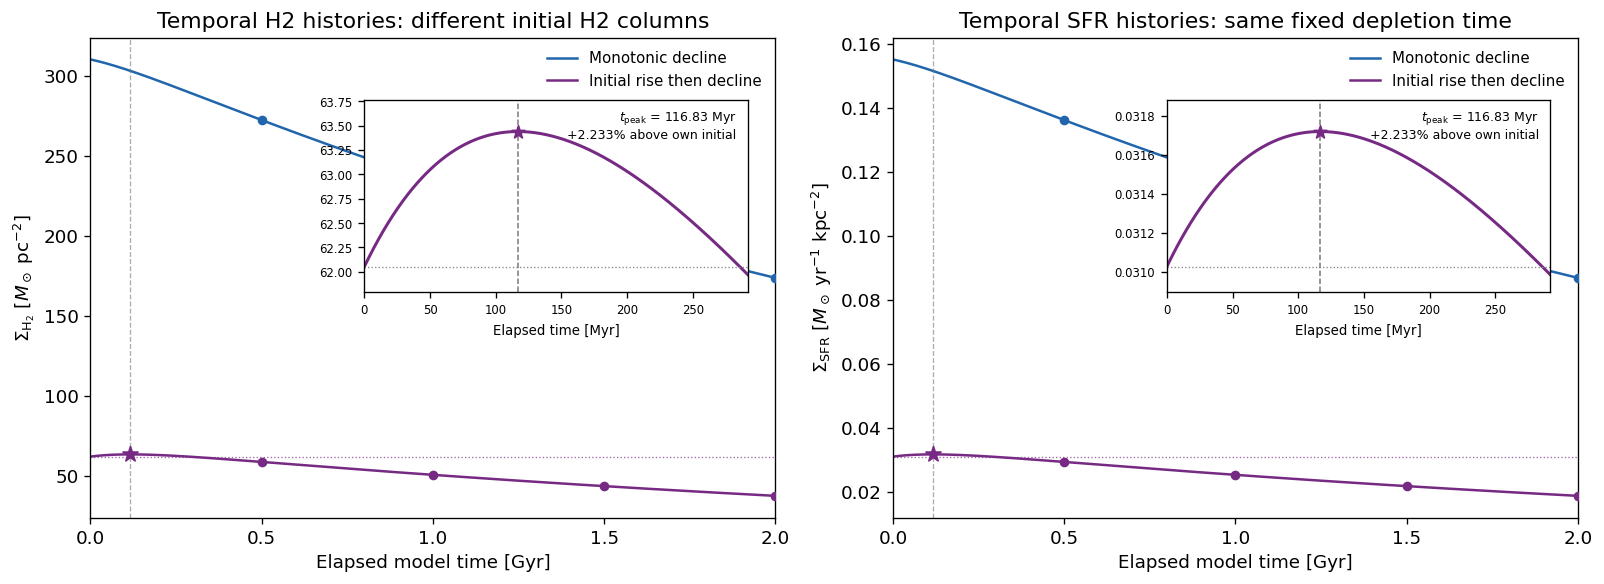

**Initial-condition response; no leading/trailing perturbation is applied here.**

,initial_condition_case,HI_0_Msun_pc2,H2_0_Msun_pc2,SFR_0_Msun_yr_kpc2,tau_Phi_0_Gyr,initial_fractional_slope_Gyr^-1,temporal_peak_time_Gyr,peak_fraction_of_own_initial,remaining_at_2Gyr
0,Monotonic decline,10.0,310.271422,0.155136,6.666667,-0.15,0.000000,1.000000,0.560006
1,Initial rise then decline,10.0,62.054284,0.031027,1.333333,0.45,0.116828,1.022326,0.604782


,initial_condition_case,time_Gyr,H2_Msun_pc2,SFR_Msun_yr_kpc2,fraction_of_own_initial
0,Monotonic decline,0.5,272.362335,0.136181,0.877820
1,Monotonic decline,1.0,234.540038,0.117270,0.755919
2,Monotonic decline,1.5,201.872999,0.100936,0.650634
3,Monotonic decline,2.0,173.753755,0.086877,0.560006
4,Initial rise then decline,0.5,58.719865,0.029360,0.946266
5,Initial rise then decline,1.0,50.656260,0.025328,0.816322
6,Initial rise then decline,1.5,43.602764,0.021801,0.702655
7,Initial rise then decline,2.0,37.529302,0.018765,0.604782


In [7]:
TEMPORAL_INITIAL_H2 = {
    'Monotonic decline': 2.0*SIGMA_H2_0,
    'Initial rise then decline': 0.4*SIGMA_H2_0,
}
TEMPORAL_COLORS = {'Monotonic decline': '#2166ac', 'Initial rise then decline': '#762a83'}
TEMPORAL_GAS = {case: gas_solution(TIME_GYR, sigma_h2_0=initial_h2)
                for case,initial_h2 in TEMPORAL_INITIAL_H2.items()}

def molecular_peak_time(sigma_h2_0, sigma_hi_0=SIGMA_HI_0, c_hi=1.0):
    """Temporal maximum for specified initial gas columns; report equation (24)."""
    supply_0 = c_hi*sigma_hi_0/TAU_CONV
    if supply_0 <= GAMMA_H2*sigma_h2_0:
        return 0.0
    tau_phi_0 = sigma_h2_0/supply_0
    rate_difference = GAMMA_HI-GAMMA_H2
    if np.isclose(rate_difference, 0.0, rtol=0, atol=1e-12):
        return 1/GAMMA_H2-tau_phi_0
    return np.log(GAMMA_HI/(GAMMA_H2*(1+rate_difference*tau_phi_0)))/rate_difference

temporal_rows = []
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    peak = molecular_peak_time(initial_h2)
    peak_state = gas_solution(peak, sigma_h2_0=initial_h2)
    tau_phi_0 = initial_h2/(SIGMA_HI_0/TAU_CONV)
    temporal_rows.append({
        'initial_condition_case': case, 'HI_0_Msun_pc2': SIGMA_HI_0,
        'H2_0_Msun_pc2': initial_h2, 'SFR_0_Msun_yr_kpc2': initial_h2/TAU_DEP*1e-3,
        'tau_Phi_0_Gyr': tau_phi_0, 'initial_fractional_slope_Gyr^-1': 1/tau_phi_0-GAMMA_H2,
        'temporal_peak_time_Gyr': peak, 'peak_fraction_of_own_initial': float(peak_state['F_SFR']),
        'remaining_at_2Gyr': float(TEMPORAL_GAS[case]['F_SFR'][-1])})
TEMPORAL_SUMMARY = pd.DataFrame(temporal_rows)
rising_case = 'Initial rise then decline'
rising_initial_h2 = TEMPORAL_INITIAL_H2[rising_case]
temporal_peak = molecular_peak_time(rising_initial_h2)
temporal_peak_state = gas_solution(temporal_peak, sigma_h2_0=rising_initial_h2)
zoom_end = min(0.5, 2.5*temporal_peak)
zoom_time = np.linspace(0.0, zoom_end, 801)
zoom_rising = gas_solution(zoom_time, sigma_h2_0=rising_initial_h2)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for case,values in TEMPORAL_GAS.items():
    color = TEMPORAL_COLORS[case]
    for ax,key in zip(axes, ('H2','SFR')):
        ax.plot(TIME_GYR, values[key], color=color, label=case)
        mark_time_checkpoints(ax, values[key], color)
for ax,key,ylabel in zip(axes, ('H2','SFR'), (
        r'$\Sigma_{\rm H_2}$ [$M_\odot$ pc$^{-2}$]',
        r'$\Sigma_{\rm SFR}$ [$M_\odot$ yr$^{-1}$ kpc$^{-2}$]')):
    ax.set(xlabel='Elapsed model time [Gyr]', ylabel=ylabel)
    initial = float(TEMPORAL_GAS[rising_case][key][0])
    ax.axhline(initial, color=TEMPORAL_COLORS[rising_case], ls=':', lw=0.8, alpha=0.7)
    ax.axvline(temporal_peak, color='#777777', ls='--', lw=0.8, alpha=0.6)
    ax.scatter(temporal_peak, temporal_peak_state[key], color=TEMPORAL_COLORS[rising_case],
               marker='*', s=90, zorder=5)
    zoom = ax.inset_axes([0.40, 0.47, 0.56, 0.40])
    zoom.plot(zoom_time*1000, zoom_rising[key], color=TEMPORAL_COLORS[rising_case], lw=1.8)
    zoom.axhline(initial, color='#888888', ls=':', lw=0.8)
    zoom.axvline(temporal_peak*1000, color='#777777', ls='--', lw=0.9)
    zoom.scatter(temporal_peak*1000, temporal_peak_state[key], color=TEMPORAL_COLORS[rising_case],
                 marker='*', s=65, zorder=5)
    zoom.set_xlim(0, zoom_end*1000)
    span = np.ptp(zoom_rising[key])
    zoom.set_ylim(zoom_rising[key].min()-0.12*span, zoom_rising[key].max()+0.22*span)
    zoom.text(0.97, 0.95, rf'$t_{{\rm peak}}$ = {temporal_peak*1000:.2f} Myr'+'\n'+
              f'+{100*(temporal_peak_state["F_SFR"]-1):.3f}% above own initial',
              transform=zoom.transAxes, ha='right', va='top', fontsize=7.5)
    zoom.set(xlabel='Elapsed time [Myr]')
    zoom.xaxis.label.set_size(8)
    zoom.tick_params(labelsize=7)
    zoom.ticklabel_format(useOffset=False)
    format_time_axis(ax)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
axes[0].set_title('Temporal H2 histories: different initial H2 columns')
axes[1].set_title('Temporal SFR histories: same fixed depletion time')
fig.tight_layout()
plt.show()
display(Markdown('**Initial-condition response; no leading/trailing perturbation is applied here.**'))
with pd.option_context('display.max_columns', None):
    display(TEMPORAL_SUMMARY)
temporal_checkpoint_rows = []
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    for time in CHECKPOINT_TIMES:
        state = gas_solution(time, sigma_h2_0=initial_h2)
        temporal_checkpoint_rows.append({
            'initial_condition_case': case, 'time_Gyr': time,
            'H2_Msun_pc2': float(state['H2']), 'SFR_Msun_yr_kpc2': float(state['SFR']),
            'fraction_of_own_initial': float(state['F_SFR'])})
TEMPORAL_CHECKPOINTS = pd.DataFrame(temporal_checkpoint_rows)
display(TEMPORAL_CHECKPOINTS)


## Spatial comparison: apply leading/trailing HI factors to either temporal reference

Now compare **positions at the same time**, separately for each of the two initial-condition
cases above. Within a case, leading/reference/trailing positions share the same initial
H$_2$ column and all coefficients. Only the initial HI column is multiplied by
$c_{\rm HI}=1.5,1,0.5$, respectively. Different rows of the figure have different common
initial H$_2$ columns, so each row has its own contemporaneous reference history.

The report's section 3.5, equations (27)--(30), gives for either reference history

$$\Sigma_{\rm H_2}(x,t)-\Sigma_{\rm H_2}^{\rm reference}(t)
=[c_{\rm HI}(x)-1]\left[\Sigma_{\rm H_2}^{\rm reference}(t)
-\Sigma_{{\rm H_2},0}e^{-\gamma_{\rm H_2}t}\right].$$

The bracket is the positive surviving molecular gas supplied after $t=0$. Therefore
$c_{\rm HI}>1$ lies above its matched reference, and $c_{\rm HI}<1$ lies below it for
every $t>0$, **whether that reference declines monotonically or initially rises**.
At $t=0$, all three positions have equal H$_2$/SFR within each case.

The spatial SFR contrast is

$$\Delta\log_{10}\Sigma_{\rm SFR}(x,t)
=\log_{10}\!\left[\frac{\Sigma_{\rm SFR}(x,t)}
{\Sigma_{\rm SFR}^{\rm reference}(t)}\right].$$

A positive spatial contrast does not imply a positive temporal derivative:

$$\left.\frac{d\Sigma_{\rm H_2}(x,t)}{dt}\right|_{t=0}
=c_{\rm HI}(x)\frac{\Sigma_{{\rm HI},0}}{\tau_{\rm conv}}
-\gamma_{\rm H_2}\Sigma_{{\rm H_2},0}.$$

The assumed initial columns were chosen so that all three spatial positions decline
in the first case, and all three initially rise before declining in the second.
Both rows nevertheless satisfy leading > reference > trailing for $t>0$. Thus spatial
enhancement/suppression is a comparison with the simultaneous reference, while an initial
rise/fall concerns a region's own time history. The table below reports the former;
temporal maxima are reported in the preceding section. These factors illustrate the
report's spatial mechanism and are not fitted NGC4654 measurements.


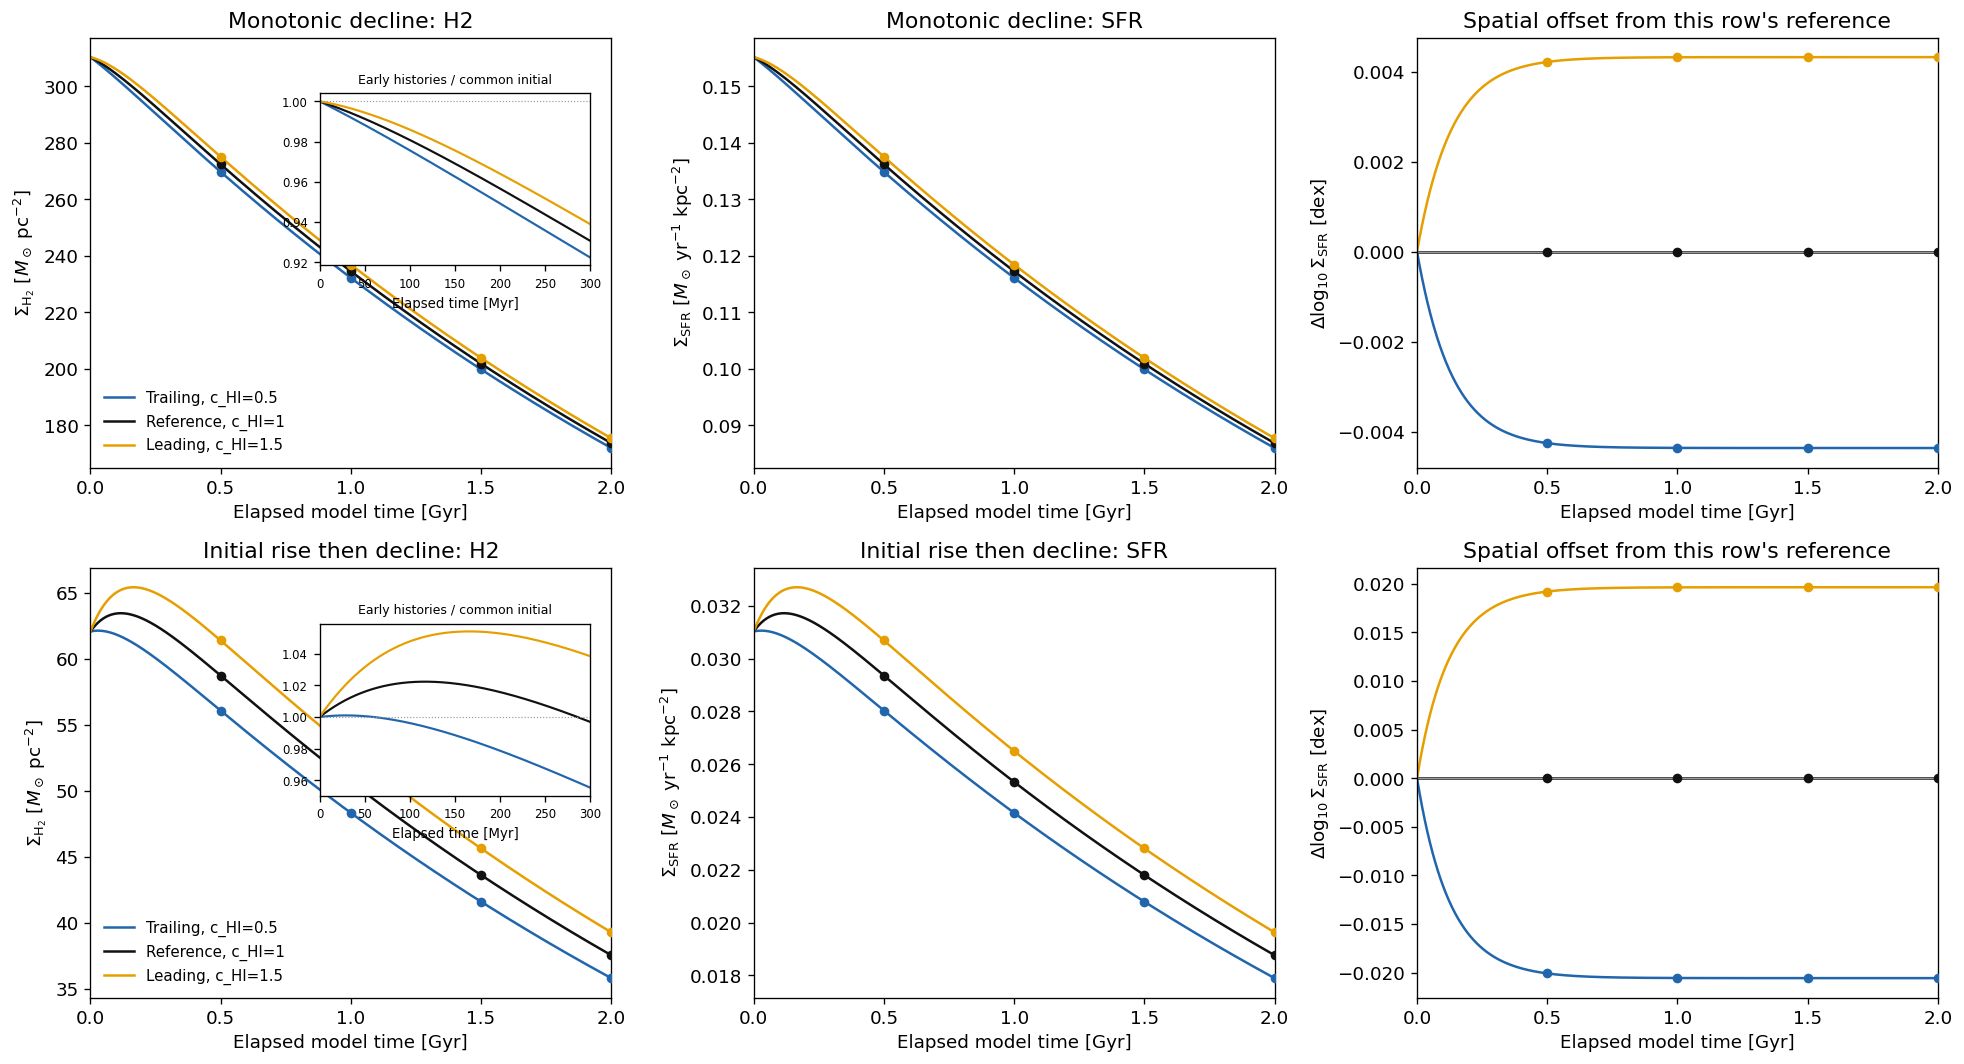

**Spatial contrasts for both reference histories. Temporal slope and spatial offset are separate columns.**

,reference_history_case,position,c_HI,common_initial_H2_Msun_pc2,initial_temporal_fractional_slope_Gyr^-1,offset_from_matched_reference_2Gyr_dex,own_remaining_SFR_2Gyr
0,Monotonic decline,trailing,0.5,310.271422,-0.225,-0.004362,0.554409
1,Monotonic decline,reference,1.0,310.271422,-0.150,0.000000,0.560006
2,Monotonic decline,leading,1.5,310.271422,-0.075,0.004319,0.565603
3,Initial rise then decline,trailing,0.5,62.054284,0.075,-0.020576,0.576797
4,Initial rise then decline,reference,1.0,62.054284,0.450,0.000000,0.604782
5,Initial rise then decline,leading,1.5,62.054284,0.825,0.019645,0.632767


,reference_history_case,time_Gyr,position,c_HI,HI_Msun_pc2,H2_Msun_pc2,SFR_Msun_yr_kpc2,fraction_of_own_initial,offset_from_matched_reference_dex
0,Monotonic decline,0.5,trailing,0.5,0.108870,269.707712,0.134854,0.869264,-0.004254
1,Monotonic decline,1.0,trailing,0.5,0.002371,232.197381,0.116099,0.748369,-0.004360
2,Monotonic decline,1.5,trailing,0.5,0.000052,199.855396,0.099928,0.644131,-0.004362
3,Monotonic decline,2.0,trailing,0.5,0.000001,172.017161,0.086009,0.554409,-0.004362
4,Monotonic decline,0.5,reference,1.0,0.217741,272.362335,0.136181,0.877820,0.000000
5,Monotonic decline,1.0,reference,1.0,0.004741,234.540038,0.117270,0.755919,0.000000
6,Monotonic decline,1.5,reference,1.0,0.000103,201.872999,0.100936,0.650634,0.000000
7,Monotonic decline,2.0,reference,1.0,0.000002,173.753755,0.086877,0.560006,0.000000
8,Monotonic decline,0.5,leading,1.5,0.326611,275.016959,0.137508,0.886375,0.004212
9,Monotonic decline,1.0,leading,1.5,0.007112,236.882696,0.118441,0.763469,0.004316


In [8]:
SPATIAL_GAS = {
    case: {region: gas_solution(TIME_GYR, c_hi=c, sigma_h2_0=initial_h2)
           for region,c in ATOMIC_FACTORS.items()}
    for case,initial_h2 in TEMPORAL_INITIAL_H2.items()}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.0))
spatial_rows, spatial_checkpoint_rows = [], []
for row,(case,initial_h2) in enumerate(TEMPORAL_INITIAL_H2.items()):
    matched_reference = SPATIAL_GAS[case]['reference']
    for region,c in ATOMIC_FACTORS.items():
        values = SPATIAL_GAS[case][region]
        color = MODEL_COLORS[region]
        label = f'{region.capitalize()}, c_HI={c:g}'
        offset = np.log10(values['SFR']/matched_reference['SFR'])
        for ax,history in zip(axes[row], (values['H2'],values['SFR'],offset)):
            ax.plot(TIME_GYR, history, color=color, label=label)
            mark_time_checkpoints(ax, history, color)
        temporal_slope = c*SIGMA_HI_0/(TAU_CONV*initial_h2)-GAMMA_H2
        spatial_rows.append({
            'reference_history_case': case, 'position': region, 'c_HI': c,
            'common_initial_H2_Msun_pc2': initial_h2,
            'initial_temporal_fractional_slope_Gyr^-1': temporal_slope,
            'offset_from_matched_reference_2Gyr_dex': float(offset[-1]),
            'own_remaining_SFR_2Gyr': float(values['F_SFR'][-1])})
        for time in CHECKPOINT_TIMES:
            local = gas_solution(time, c_hi=c, sigma_h2_0=initial_h2)
            simultaneous = gas_solution(time, sigma_h2_0=initial_h2)
            spatial_checkpoint_rows.append({
                'reference_history_case': case, 'time_Gyr': time, 'position': region, 'c_HI': c,
                'HI_Msun_pc2': float(local['HI']), 'H2_Msun_pc2': float(local['H2']),
                'SFR_Msun_yr_kpc2': float(local['SFR']), 'fraction_of_own_initial': float(local['F_SFR']),
                'offset_from_matched_reference_dex': float(np.log10(local['SFR']/simultaneous['SFR']))})
    axes[row,0].set_ylabel(r'$\Sigma_{\rm H_2}$ [$M_\odot$ pc$^{-2}$]')
    axes[row,1].set_ylabel(r'$\Sigma_{\rm SFR}$ [$M_\odot$ yr$^{-1}$ kpc$^{-2}$]')
    axes[row,2].set_ylabel(r'$\Delta\log_{10}\Sigma_{\rm SFR}$ [dex]')
    axes[row,2].axhline(0, color='#999999', lw=0.7)
    for ax in axes[row]:
        ax.set_xlabel('Elapsed model time [Gyr]')
        format_time_axis(ax)
    axes[row,0].set_title(case+': H2')
    axes[row,1].set_title(case+': SFR')
    axes[row,2].set_title('Spatial offset from this row\'s reference')
    axes[row,0].legend(frameon=False, fontsize=9, loc='lower left')
    # Show early spatial separation without using a temporal peak as its definition.
    zoom = axes[row,0].inset_axes([0.44, 0.47, 0.52, 0.40])
    early_time = np.linspace(0, 0.30, 601)
    for region,c in ATOMIC_FACTORS.items():
        local = gas_solution(early_time, c_hi=c, sigma_h2_0=initial_h2)
        zoom.plot(early_time*1000, local['F_SFR'], color=MODEL_COLORS[region], lw=1.3)
    zoom.axhline(1, color='#999999', ls=':', lw=0.7)
    zoom.set(xlim=(0,300), xlabel='Elapsed time [Myr]')
    zoom.set_title('Early histories / common initial', fontsize=7.5)
    zoom.xaxis.label.set_size(8)
    zoom.tick_params(labelsize=7)
    zoom.ticklabel_format(useOffset=False)
fig.tight_layout()
plt.show()
SPATIAL_SUMMARY = pd.DataFrame(spatial_rows)
SPATIAL_CHECKPOINTS = pd.DataFrame(spatial_checkpoint_rows)
display(Markdown('**Spatial contrasts for both reference histories. Temporal slope and spatial offset are separate columns.**'))
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(SPATIAL_SUMMARY)
    display(SPATIAL_CHECKPOINTS)


## Connect SFR to the luminosity budget

We use the report's instantaneous young-star H$\alpha$ approximation, equations (31)--(40).
It is appropriate here because the imposed gas evolution is slower than the massive-star
response. For any remaining-SFR fraction $F$,

$$\mathcal L_\alpha^{\rm young}=\mathcal L_{\alpha,0}^{\rm young}F,\qquad
w_{\rm HOLMES}=\frac{\mathcal L_\alpha^{\rm HOLMES}}{
\mathcal L_{\alpha,0}^{\rm young}F+\mathcal L_\alpha^{\rm HOLMES}}.$$

The initial normalization of each young template is
$R_{\ell/B}^{\rm young}=(R_{\ell/B,0}^{\rm observed}-w_0R_{\ell/B}^{\rm HOLMES})/(1-w_0)$.
This reproduces the initial observed SF reference by construction and then keeps both
intrinsic spectra constant. It does not identify the true component spectra.

Because the Balmer decrements are equal, the same weight applies to N2, S2, and O3.
The code computes individual component **line luminosities first**, sums them, and then
forms the ratios. During a declining-SFR phase, both numerator and denominator may fade
while the ratio increases. The H$\alpha$-equivalent apparent SFR, $C_\alpha\mathcal L_\alpha$,
contains HOLMES and approaches a floor; the true model SFR continues to decline.

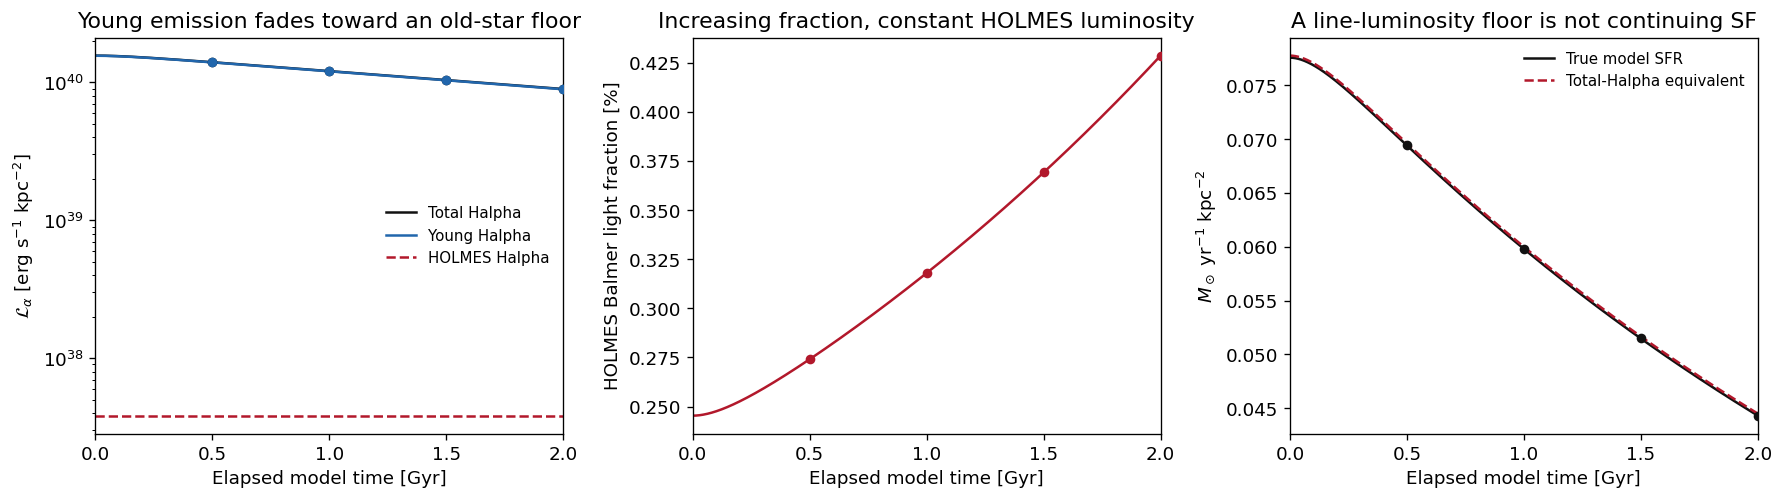

In [9]:
def emission_solution(sfr_fraction):
    fraction = np.asarray(sfr_fraction, dtype=float)
    young_ha = L_ALPHA_YOUNG_0*fraction
    holmes_ha = np.full_like(fraction, L_ALPHA_HOLMES)
    young = {'Halpha': young_ha, 'Hbeta': young_ha/BALMER_DECREMENT}
    holmes = {'Halpha': holmes_ha, 'Hbeta': holmes_ha/BALMER_DECREMENT}
    for ratio,line,balmer in [('N2','NII','Halpha'), ('S2','SII','Halpha'), ('O3','OIII','Hbeta')]:
        young[line] = YOUNG_RATIOS[ratio]*young[balmer]
        holmes[line] = HOLMES_RATIOS[ratio]*holmes[balmer]
    total = {line: young[line]+holmes[line] for line in young}
    weight = holmes_ha/total['Halpha']
    ratios = {'N2': total['NII']/total['Halpha'], 'S2': total['SII']/total['Halpha'],
              'O3': total['OIII']/total['Hbeta']}
    return {'young': young, 'HOLMES': holmes, 'total': total, 'weight': weight, 'ratios': ratios}

EMISSION = emission_solution(reference['F_SFR'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for label, values, color, style in [
    ('Total Halpha', EMISSION['total']['Halpha'], '#111111', '-'),
    ('Young Halpha', EMISSION['young']['Halpha'], '#2166ac', '-'),
    ('HOLMES Halpha', EMISSION['HOLMES']['Halpha'], '#b2182b', '--')]:
    axes[0].plot(TIME_GYR, values, color=color, ls=style, label=label)
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$\mathcal{L}_\alpha$ [erg s$^{-1}$ kpc$^{-2}$]')
axes[0].set_title('Young emission fades toward an old-star floor')
axes[1].plot(TIME_GYR, EMISSION['weight']*100, color='#b2182b')
axes[1].set_ylabel('HOLMES Balmer light fraction [%]')
axes[1].set_title('Increasing fraction, constant HOLMES luminosity')
axes[2].plot(TIME_GYR, reference['SFR'], color='#111111', label='True model SFR')
axes[2].plot(TIME_GYR, C_ALPHA*EMISSION['total']['Halpha'], '--', color='#b2182b',
             label='Total-Halpha equivalent')
axes[2].set_ylabel(r'$M_\odot$ yr$^{-1}$ kpc$^{-2}$')
axes[2].set_title('A line-luminosity floor is not continuing SF')
for ax in axes:
    ax.set_xlabel('Elapsed model time [Gyr]')
    format_time_axis(ax)
axes[0].legend(frameon=False, fontsize=9)
axes[2].legend(frameon=False, fontsize=9)
mark_time_checkpoints(axes[0], EMISSION['total']['Halpha'], '#111111')
mark_time_checkpoints(axes[0], EMISSION['young']['Halpha'], '#2166ac')
mark_time_checkpoints(axes[1], EMISSION['weight']*100, '#b2182b')
mark_time_checkpoints(axes[2], reference['SFR'], '#111111')
fig.tight_layout()
plt.show()

## Differential line fading and ratio growth

The first figure below is the **coupled gas prediction over 0--2 Gyr**. Each line is
normalized by its own initial total luminosity. Equal Balmer decrements make H$\alpha$
and H$\beta$ fade identically. Larger HOLMES forbidden-line ratios make those lines
fade more slowly, while all absolute luminosities decrease in this reference history.

The second figure extends the **same mixing equations** over $10^{-4}\leq F\leq1$.
This is a relation between remaining young emission and the line spectrum. Values beyond
the 2-Gyr endpoint are algebraic extrapolations, not additional elapsed-time predictions.
The marker shows how far the adopted gas model actually evolves by 2 Gyr. In particular,
a visually strong ratio rise can require much more SFR suppression than this gas model
produces in the plotted time interval.

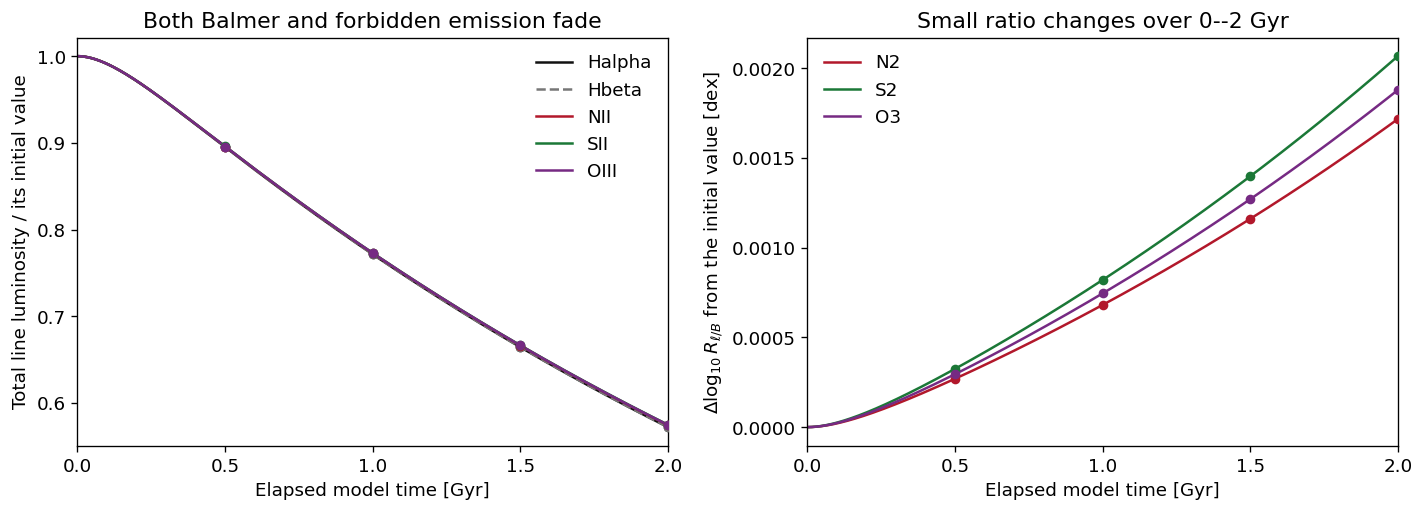

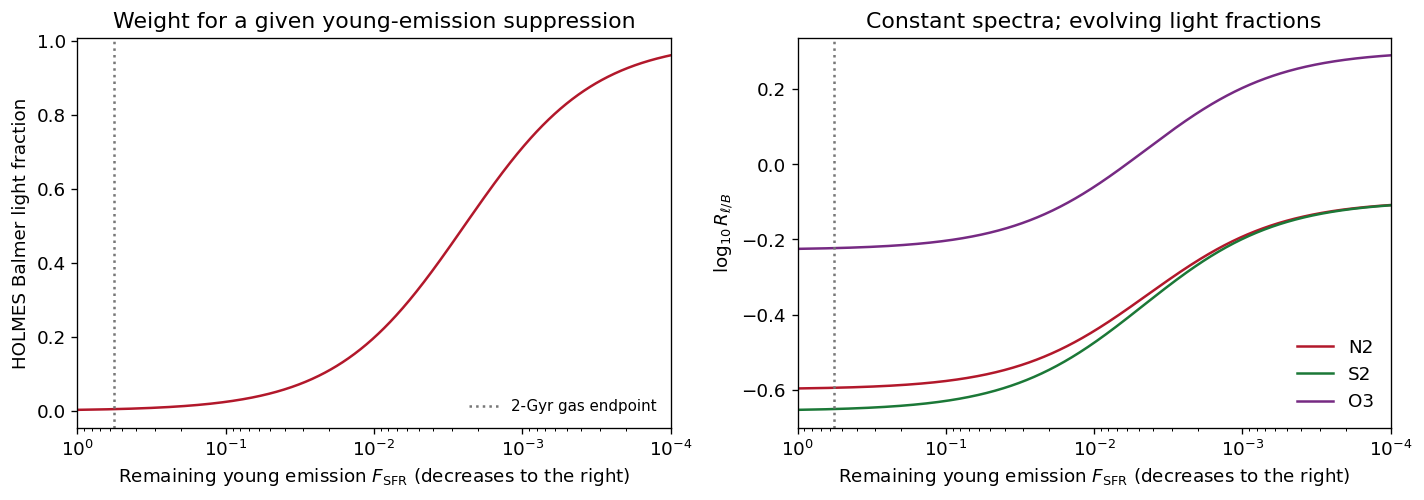

**Reference predictions.** SFR has units Msun yr^-1 kpc^-2; Halpha surface luminosities have units erg s^-1 kpc^-2. N2, S2 and O3 are linear ratios; their changes are logarithmic dex.

,time_Gyr,SFR_Msun_yr_kpc2,remaining_SFR,HOLMES_weight_percent,Halpha_total_erg_s_kpc2,Halpha_young_erg_s_kpc2,N2,S2,O3,delta_log_N2_dex,delta_log_S2_dex,delta_log_O3_dex
0,0.0,0.077568,1.000000,0.245334,1.561418e+40,1.557587e+40,0.253591,0.222488,0.595529,0.000000,0.000000,0.000000
1,0.5,0.069418,0.894931,0.274058,1.397764e+40,1.393934e+40,0.253749,0.222655,0.595933,0.000269,0.000324,0.000295
2,1.0,0.059806,0.771020,0.317963,1.204761e+40,1.200930e+40,0.253989,0.222909,0.596551,0.000681,0.000820,0.000745
3,1.5,0.051477,0.663639,0.369221,1.037506e+40,1.033676e+40,0.254270,0.223205,0.597273,0.001161,0.001398,0.001270
4,2.0,0.044307,0.571200,0.428717,8.935242e+39,8.896935e+39,0.254596,0.223550,0.598111,0.001717,0.002067,0.001879


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for line,color in LINE_COLORS.items():
    series = EMISSION['total'][line]
    axes[0].plot(TIME_GYR, series/series[0], color=color,
                 ls='--' if line == 'Hbeta' else '-', label=line)
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    axes[1].plot(TIME_GYR, np.log10(EMISSION['ratios'][ratio]/EMISSION['ratios'][ratio][0]), color=color, label=ratio)
axes[0].set(xlabel='Elapsed model time [Gyr]', ylabel='Total line luminosity / its initial value',
            title='Both Balmer and forbidden emission fade')
axes[1].set(xlabel='Elapsed model time [Gyr]', ylabel=r'$\Delta\log_{10} R_{\ell/B}$ from the initial value [dex]',
            title='Small ratio changes over 0--2 Gyr')
for ax in axes:
    ax.legend(frameon=False)
    format_time_axis(ax)
for line,color in LINE_COLORS.items():
    values = EMISSION['total'][line]
    mark_time_checkpoints(axes[0], values/values[0], color)
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    values = EMISSION['ratios'][ratio]
    mark_time_checkpoints(axes[1], np.log10(values/values[0]), color)
fig.tight_layout()
plt.show()

FADE_GRID = np.geomspace(1.0, 1e-4, 701)
FADE_EMISSION = emission_solution(FADE_GRID)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(FADE_GRID, FADE_EMISSION['weight'], color='#b2182b')
axes[0].set(ylabel='HOLMES Balmer light fraction', title='Weight for a given young-emission suppression')
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    axes[1].plot(FADE_GRID, np.log10(FADE_EMISSION['ratios'][ratio]), color=color, label=ratio)
axes[1].set(ylabel=r'$\log_{10} R_{\ell/B}$', title='Constant spectra; evolving light fractions')
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(1, 1e-4)
    ax.axvline(reference['F_SFR'][-1], color='#777777', ls=':', label='2-Gyr gas endpoint')
    ax.set_xlabel(r'Remaining young emission $F_{\rm SFR}$ (decreases to the right)')
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

emission_rows = []
for time in np.r_[0.0, CHECKPOINT_TIMES]:
    gas = gas_solution(time)
    spectrum = emission_solution(gas['F_SFR'])
    emission_rows.append({
        'time_Gyr': time, 'SFR_Msun_yr_kpc2': float(gas['SFR']),
        'remaining_SFR': float(gas['F_SFR']), 'HOLMES_weight_percent': 100*float(spectrum['weight']),
        'Halpha_total_erg_s_kpc2': float(spectrum['total']['Halpha']),
        'Halpha_young_erg_s_kpc2': float(spectrum['young']['Halpha']),
        **{name: float(value) for name,value in spectrum['ratios'].items()},
        **{f'delta_log_{name}_dex': float(np.log10(value/EMISSION['ratios'][name][0]))
           for name,value in spectrum['ratios'].items()}})
EMISSION_SUMMARY = pd.DataFrame(emission_rows)
display(Markdown('**Reference predictions.** SFR has units Msun yr^-1 kpc^-2; Halpha surface luminosities have units erg s^-1 kpc^-2. N2, S2 and O3 are linear ratios; their changes are logarithmic dex.'))
with pd.option_context('display.max_columns', None):
    display(EMISSION_SUMMARY)


## BPT-plane prediction, standard demarcations, and MAUVE comparison

The solid black track is the coupled gas model over **0--2 Gyr**. Markers identify
**0.5, 1.0, 1.5, and 2.0 Gyr**, and the insets resolve the small predicted displacement.
The dashed grey continuation is the algebraic mixing curve down to $F=10^{-4}$;
it is not an additional prediction within 2 Gyr. Endpoints are the constant young
and HOLMES templates. SF/NSF symbols are the freshly measured stage summaries and are
not pure ionization templates. The model has not been fitted to the NSF points.

Every BPT panel uses the standard demarcation relations for its plane. Define
$x_{\rm N2}=\log_{10}([\mathrm{N\,II}]/\mathrm H\alpha)$,
$x_{\rm S2}=\log_{10}([\mathrm{S\,II}]/\mathrm H\alpha)$, and
$y=\log_{10}([\mathrm{O\,III}]/\mathrm H\beta)$:

$$\begin{aligned}
y_{\rm Ke01,N2}&=\frac{0.61}{x_{\rm N2}-0.47}+1.19,\qquad x_{\rm N2}<0.47,\\
y_{\rm Ka03,N2}&=\frac{0.61}{x_{\rm N2}-0.05}+1.30,\qquad x_{\rm N2}<0.05,\\
y_{\rm Ke01,S2}&=\frac{0.72}{x_{\rm S2}-0.32}+1.30,\qquad x_{\rm S2}<0.32,\\
y_{\rm Ke06,S2}&=1.89x_{\rm S2}+0.76.
\end{aligned}$$

Ke01 is the maximum-starburst boundary in both planes
([Kewley et al. 2001, equations 5--6](https://arxiv.org/pdf/astro-ph/0106324));
Ka03 is the empirical SF boundary in the **N2 plane**
([Kauffmann et al. 2003, equation 1](https://arxiv.org/pdf/astro-ph/0304239));
Ke06 divides Seyfert/LINER-like excitation in the **S2 plane**, above Ke01
([Kewley et al. 2006, equation 10 and Figure 4](https://arxiv.org/pdf/astro-ph/0605681)).
We draw Ke06 from its intersection with Ke01 onwards. The helper below is called
for both main panels and both insets, and restricts hyperbolae to their left branches.
In the zoomed model insets the boundaries lie outside the visible narrow range.
These are **demarcation curves**, distinct from the Balmer decrement Halpha/Hbeta = 2.86.
The curves label excitation regions; they do not by themselves identify the physical ionizing source.


**How to read the NSF squares.** NSF is the project's selection category, not a requirement
to lie above an individual BPT curve and not a pure HOLMES component. The audit immediately
after the BPT figure quantifies its membership and the plotted stage-point locations.


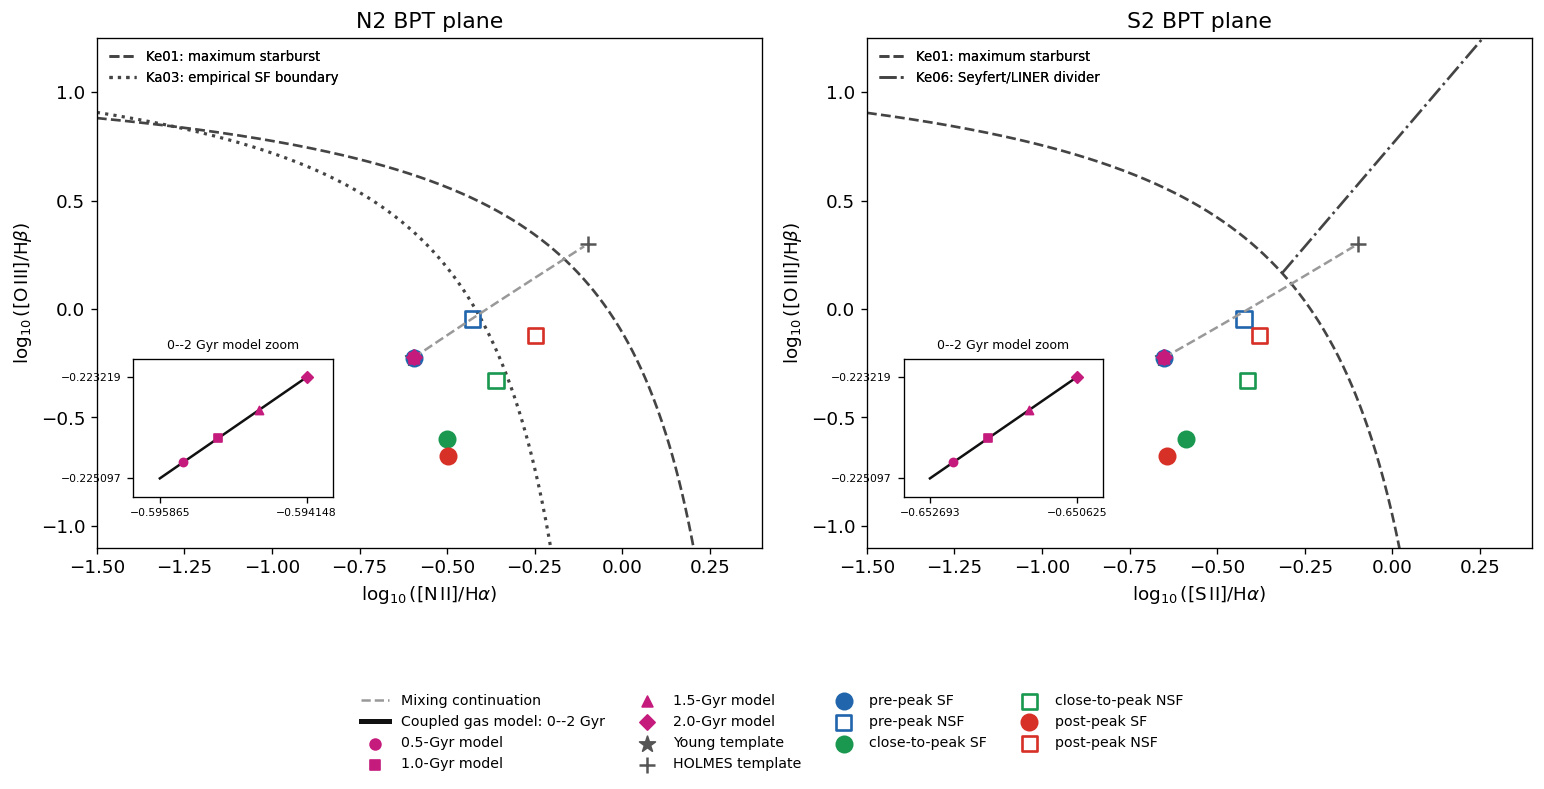

In [11]:
def plot_bpt_demarcations(ax, plane, xlimits, *, legend_labels=True):
    """Standard Ke01/Ka03/Ke06 relations; only the appropriate BPT plane."""
    label = lambda text: text if legend_labels else '_nolegend_'
    artists = []
    lo, hi = xlimits
    if plane == 'N2':
        x = np.linspace(lo, min(hi, 0.47-0.01), 800)
        artists += ax.plot(x, 0.61/(x-0.47)+1.19, '--', color='#444444', lw=1.6,
                           label=label('Ke01: maximum starburst'), zorder=1)
        x = np.linspace(lo, min(hi, 0.05-0.01), 800)
        artists += ax.plot(x, 0.61/(x-0.05)+1.30, ':', color='#444444', lw=1.9,
                           label=label('Ka03: empirical SF boundary'), zorder=1)
    elif plane == 'S2':
        x = np.linspace(lo, min(hi, 0.32-0.01), 800)
        artists += ax.plot(x, 0.72/(x-0.32)+1.30, '--', color='#444444', lw=1.6,
                           label=label('Ke01: maximum starburst'), zorder=1)
        intersection = (159-np.sqrt(105081))/525
        if hi > intersection:
            x = np.linspace(max(lo, intersection), hi, 300)
            artists += ax.plot(x, 1.89*x+0.76, '-.', color='#444444', lw=1.6,
                               label=label('Ke06: Seyfert/LINER divider'), zorder=1)
    else:
        raise ValueError(f'Unsupported BPT plane: {plane}')
    return artists

CHECKPOINT_SPECTRA = [emission_solution(gas_solution(time)['F_SFR']) for time in CHECKPOINT_TIMES]
fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
BPT_AXES_AUDIT = []
for ax, xratio in zip(axes, ('N2','S2')):
    xlimits, ylimits = (-1.5, 0.4), (-1.1, 1.25)
    demarcations = plot_bpt_demarcations(ax, xratio, xlimits)
    curve_legend = ax.legend(handles=demarcations, loc='upper left', frameon=False, fontsize=8)
    ax.add_artist(curve_legend)
    ax.plot(np.log10(FADE_EMISSION['ratios'][xratio]), np.log10(FADE_EMISSION['ratios']['O3']),
            '--', color='#999999', lw=1.5, label='Mixing continuation')
    ax.plot(np.log10(EMISSION['ratios'][xratio]), np.log10(EMISSION['ratios']['O3']),
            color='#111111', lw=3, label='Coupled gas model: 0--2 Gyr')
    for time,marker,spectrum in zip(CHECKPOINT_TIMES, CHECKPOINT_MARKERS, CHECKPOINT_SPECTRA):
        ax.scatter(np.log10(spectrum['ratios'][xratio]), np.log10(spectrum['ratios']['O3']),
                   color='#c51b7d', marker=marker, s=42, zorder=5, label=f'{time:.1f}-Gyr model')
    for template, ratios, marker in [('Young template', YOUNG_RATIOS, '*'),
                                     ('HOLMES template', HOLMES_RATIOS, '+')]:
        ax.scatter(np.log10(ratios[xratio]), np.log10(ratios['O3']), marker=marker,
                   color='#555555', s=100, label=template)
    for row in OBS_STAGE.itertuples(index=False):
        color = STAGE_COLORS[row.stage]
        ax.scatter(np.log10(getattr(row,xratio)), np.log10(row.O3), s=85,
                   marker='o' if row.category == 'SF' else 's',
                   facecolors=color if row.category == 'SF' else 'none', edgecolors=color, lw=1.6,
                   label=f'{row.stage} {row.category}')
    ax.set_xlim(xlimits)
    ax.set_ylim(ylimits)
    xlabel = (r'$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$' if xratio == 'N2'
              else r'$\log_{10}([\mathrm{S\,II}]/\mathrm{H}\alpha)$')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$\log_{10}([\mathrm{O\,III}]/\mathrm{H}\beta)$')
    ax.set_title(xratio+' BPT plane')
    # Resolve the checkpoints while retaining actual BPT coordinates.
    zoom = ax.inset_axes([0.055, 0.10, 0.30, 0.27])
    model_x = np.log10(EMISSION['ratios'][xratio])
    model_y = np.log10(EMISSION['ratios']['O3'])
    pad_x, pad_y = 0.18*np.ptp(model_x), 0.18*np.ptp(model_y)
    zoom_limits = (model_x.min()-pad_x, model_x.max()+pad_x)
    plot_bpt_demarcations(zoom, xratio, zoom_limits, legend_labels=False)
    zoom.plot(model_x, model_y, color='#111111', lw=1.5)
    for time,marker,spectrum in zip(CHECKPOINT_TIMES, CHECKPOINT_MARKERS, CHECKPOINT_SPECTRA):
        zoom.scatter(np.log10(spectrum['ratios'][xratio]), np.log10(spectrum['ratios']['O3']),
                     color='#c51b7d', marker=marker, s=24, zorder=5)
    zoom.set_xlim(zoom_limits)
    zoom.set_ylim(model_y.min()-pad_y, model_y.max()+pad_y)
    zoom.set_title('0--2 Gyr model zoom', fontsize=7.5)
    zoom.set_xticks([model_x.min(), model_x.max()])
    zoom.set_yticks([model_y.min(), model_y.max()])
    zoom.tick_params(labelsize=6.5)
    zoom.ticklabel_format(useOffset=False)
    BPT_AXES_AUDIT.append({'plane':xratio, 'main':ax, 'zoom':zoom,
                           'demarcation_labels':[line.get_label() for line in demarcations]})
handles, labels = axes[1].get_legend_handles_labels()
handles, labels = zip(*[(h,l) for h,l in zip(handles,labels) if not l.startswith(('Ke01','Ke06'))])
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, fontsize=8.5,
           bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=(0, 0.20, 1, 1))
plt.show()


## Why can the observed NSF points lie below the BPT boundaries?

The selection in this notebook is exactly

$$\mathrm{SF}=\mathrm{usable}\cap\mathrm{finite\ HII\ SFR}
\cap\{\mathrm{EW}(\mathrm H\alpha)>6\ \mathring{\mathrm A}\}
\cap\{\sigma_{\mathrm H\alpha,\rm intrinsic}<45\ \mathrm{km\ s^{-1}}\},$$
$$\mathrm{NSF}=\mathrm{usable}\cap\mathrm{Balmer\ detected}\cap\neg\mathrm{SF}.$$

Consequently, low-EW or broad-line regions can be NSF with HII-like BPT ratios. Failure
of HII eligibility can also reflect the other BPT plane or an uncertainty-sensitive
classification. It does not by itself establish a HOLMES-dominated source. Failing an EW or dispersion
cut also does not prove that current star formation is absent.

In N2, points between Ka03 and Ke01 are Composite-like even though they lie below
Ke01. Ke06 is a Seyfert/LINER divider above the S2 Ke01 boundary, not an additional
HII/non-HII boundary. The pixel tests below use the appropriate SF boundary in
each plane; the plotted NSF averages are checked independently.

We check **the actual maps**, using the same mass window, SNR cut, common corrected-line
support, and eligible products as the plotted NSF stage points. The table partitions
NSF by its first failed SF gate (HII map, then EW, then dispersion). The separate BPT
diagnostic evaluates each pixel's central corrected ratios below Ka03/Ke01 in N2 and
below Ke01 in S2, and reports the stored confidence-sensitive class maps.

The live [`SFR+Z.py`](SFR+Z.py) source distinguishes these two classification products:
`NII_BPT`/`SII_BPT` assign positive codes only when the central and four displaced
$\pm1\sigma$ positions have the **same exact** class. In contrast, the HII-SFR map
with `BPTMODE='both'` uses central N2 HII membership with displaced points allowed in
the combined HII+Composite envelope, together with displaced S2 HII membership
(source lines 3237--3272, 3477, 3500--3554, and 3600--3622). We therefore use finite
HII SFR for the original gate; we do **not** replace it with two positive HII class codes.
Stored codes are N2: 1 HII, 2 Composite, 3 AGN-like; S2: 1 HII, 2 LINER-like, 3 Seyfert-like;
0 is unclassified and -1 is unknown/non-detected. These names describe excitation classes.

There is also an averaging distinction. With $\overline{\mathcal L}_{\ell,g}$ the mean
surface luminosity within product $g$, the plotted stage ratio is

$$R_{\ell/B}^{\rm stage}
=\frac{\sum_g\overline{\mathcal L}_{\ell,g}}{\sum_g\overline{\mathcal L}_{B,g}}
=\sum_g\frac{\overline{\mathcal L}_{B,g}}{\sum_h\overline{\mathcal L}_{B,h}}
\frac{\overline{\mathcal L}_{\ell,g}}{\overline{\mathcal L}_{B,g}}.$$

Products enter the **luminosity means** equally, while the resulting ratio is
Balmer-light weighted. Halpha weights N2/S2; Hbeta weights O3. The stage point is
therefore not the mean log-ratio position of its pixels, and a nonlinear demarcation
is not a rule for assigning the aggregate the category of every constituent pixel.
We explicitly test the final stage coordinates rather than inferring their class
from the NSF label. Central pixel fractions below different curves may overlap.

The gate chart is an exclusive partition. Its Halpha shares use the same mean-luminosity
estimator as the plotted stage points. Pixel fractions in the second panel are averaged
equally across supported products; they are descriptive, without treating pixels as
independent galaxies. The full per-product diagnostic is retained as
`NSF_DIAGNOSTICS_BY_GALAXY` for inspection.


**Direct check of the plotted NSF stage coordinates.** Negative offsets lie below the indicated boundary.

,stage,log_N2,log_S2,log_O3,N2_stage_below_SF_boundaries,S2_stage_below_Ke01,O3_minus_Ka03_N2_dex,O3_minus_Ke01_S2_dex
0,pre-peak,-0.428222,-0.423316,-0.046828,True,True,-0.071269,-0.378195
1,close-to-peak,-0.359848,-0.413741,-0.329942,True,True,-0.141586,-0.648670
2,post-peak,-0.246948,-0.380035,-0.123340,False,True,0.630891,-0.394820


,stage,kind,selection,N_products,N_selected_pixels,mean_product_pixel_fraction,stage_Halpha_fraction
0,post-peak,first failed SF gate,HII SFR unavailable; stable non-HII in at least one BPT plane,13,72772,0.428085,0.290269
1,post-peak,first failed SF gate,HII SFR unavailable; no stable non-HII and not both stable HII,13,44358,0.432783,0.435849
2,post-peak,first failed SF gate,HII SFR unavailable despite both stable HII,13,0,0.000000,0.000000
3,post-peak,first failed SF gate,HII SFR available; EW missing,13,0,0.000000,0.000000
4,post-peak,first failed SF gate,HII SFR available; EW <= 6 Angstrom,13,3024,0.112262,0.131728
5,post-peak,first failed SF gate,HII SFR and EW pass; intrinsic dispersion missing,13,0,0.000000,0.000000
6,post-peak,first failed SF gate,HII SFR and EW pass; intrinsic dispersion >= 45 km/s,13,1914,0.026870,0.142155
7,post-peak,BPT location/class,central N2 HII-like,13,4943,0.139165,0.273885
8,post-peak,BPT location/class,central S2 HII-like,13,38710,0.571913,0.866058
9,post-peak,BPT location/class,central HII-like in both planes,13,4943,0.139165,0.273885


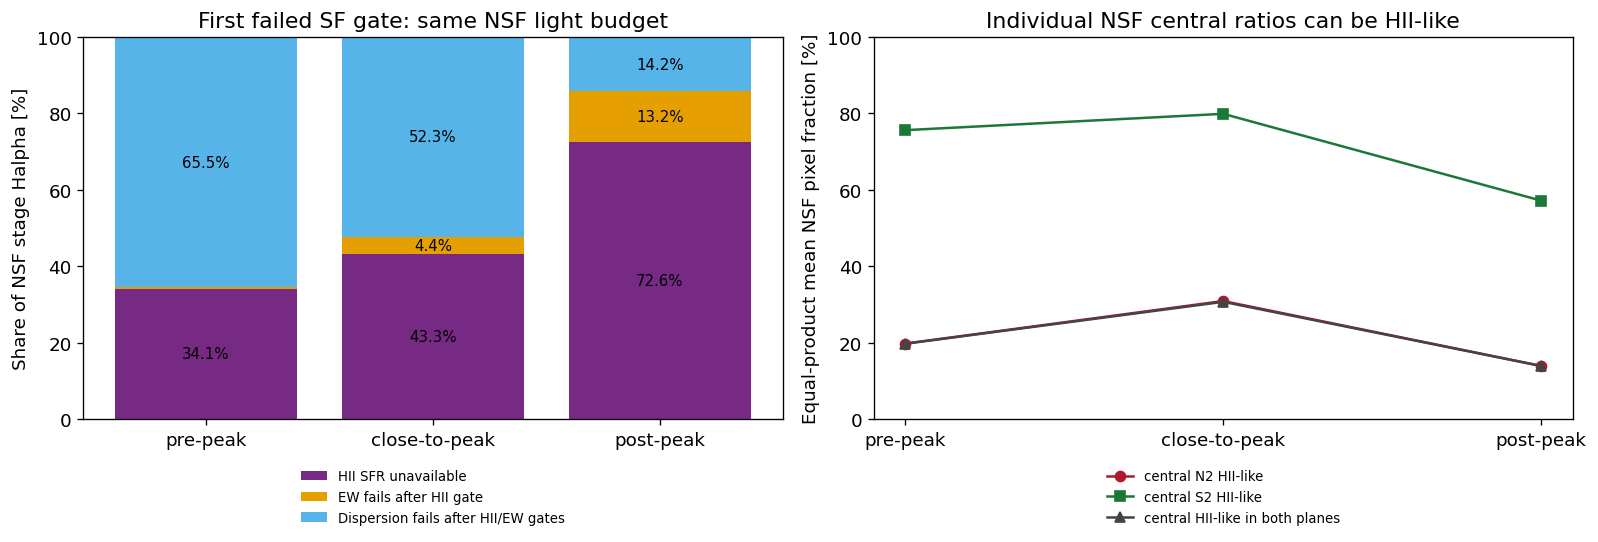

### What the live NSF audit establishes

- **pre-peak:** 0.4% of NSF Halpha comes from the EW-failure branch and 65.5% from the dispersion-failure branch, after the preceding gates pass. The equal-product mean central HII-like pixel fractions are 19.8% (N2) and 75.6% (S2).
- **close-to-peak:** 4.4% of NSF Halpha comes from the EW-failure branch and 52.3% from the dispersion-failure branch, after the preceding gates pass. The equal-product mean central HII-like pixel fractions are 30.9% (N2) and 79.9% (S2).
- **post-peak:** 13.2% of NSF Halpha comes from the EW-failure branch and 14.2% from the dispersion-failure branch, after the preceding gates pass. The equal-product mean central HII-like pixel fractions are 13.9% (N2) and 57.2% (S2).

A below-curve NSF point is therefore compatible with the category definition. Use the gate and coordinate tables to distinguish HII-like regions outside the SF cuts from BPT non-HII excitation. Neither the whole NSF sample nor its averaged square can be interpreted as a pure HOLMES template. The existing model track remains a mechanism illustration, not a fit to this heterogeneous category.

In [12]:
diagnostic_stage_rows = []
for (stage,kind,selection), group in NSF_DIAGNOSTICS_BY_GALAXY.loc[
        NSF_DIAGNOSTICS_BY_GALAXY.eligible].groupby(['stage','kind','selection'], sort=False):
    expected = OBS_STAGE.loc[(OBS_STAGE.stage == stage) & (OBS_STAGE.category == 'NSF')].iloc[0]
    assert set(group.GALID) == set(expected.GALIDs.split(', '))
    diagnostic_stage_rows.append({
        'stage': stage, 'kind': kind, 'selection': selection, 'N_products': len(group),
        'N_selected_pixels': int(group.N_selected.sum()),
        'mean_product_pixel_fraction': float(group.pixel_fraction.mean()),
        'stage_Halpha_fraction': float(group.Halpha_contribution.mean()/expected.Halpha)})
NSF_DIAGNOSTICS_STAGE = pd.DataFrame(diagnostic_stage_rows)
NSF_STAGE_LOCATIONS = []
for row in OBS_STAGE.loc[OBS_STAGE.category == 'NSF'].itertuples(index=False):
    n2_hii, s2_hii = central_hii_masks(row.N2, row.S2, row.O3)
    x_n2, x_s2, y = np.log10(row.N2), np.log10(row.S2), np.log10(row.O3)
    NSF_STAGE_LOCATIONS.append({
        'stage': row.stage, 'log_N2': x_n2, 'log_S2': x_s2, 'log_O3': y,
        'N2_stage_below_SF_boundaries': bool(n2_hii),
        'S2_stage_below_Ke01': bool(s2_hii),
        'O3_minus_Ka03_N2_dex': y-(0.61/(x_n2-0.05)+1.30),
        'O3_minus_Ke01_S2_dex': y-(0.72/(x_s2-0.32)+1.30)})
NSF_STAGE_LOCATIONS = pd.DataFrame(NSF_STAGE_LOCATIONS)
display(Markdown('**Direct check of the plotted NSF stage coordinates.** Negative offsets lie below the indicated boundary.'))
with pd.option_context('display.max_columns', None, 'display.max_colwidth', 85, 'display.max_rows', None):
    display(NSF_STAGE_LOCATIONS)
    display(NSF_DIAGNOSTICS_STAGE)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
stage_x = np.arange(len(STAGES))
gate_groups = [NSF_GATE_LABELS[:3], NSF_GATE_LABELS[3:5], NSF_GATE_LABELS[5:]]
bottom = np.zeros(len(STAGES))
for labels,color,label in zip(gate_groups, ('#762a83','#e69f00','#56b4e9'),
                              ('HII SFR unavailable','EW fails after HII gate','Dispersion fails after HII/EW gates')):
    shares = np.array([NSF_DIAGNOSTICS_STAGE.loc[
        (NSF_DIAGNOSTICS_STAGE.stage == stage) & NSF_DIAGNOSTICS_STAGE.selection.isin(labels),
        'stage_Halpha_fraction'].sum() for stage in STAGES])
    axes[0].bar(stage_x, 100*shares, bottom=100*bottom, color=color, label=label)
    for x,height,base in zip(stage_x, 100*shares, 100*bottom):
        if height >= 4:
            axes[0].text(x, base+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=9)
    bottom += shares
np.testing.assert_allclose(bottom, 1.0, rtol=1e-12)
axes[0].set(ylabel='Share of NSF stage Halpha [%]', ylim=(0,100), title='First failed SF gate: same NSF light budget')
for label,color,marker in zip(NSF_CENTRAL_LABELS[:3], ('#b2182b','#1b7837','#444444'), ('o','s','^')):
    values = [float(NSF_DIAGNOSTICS_STAGE.loc[(NSF_DIAGNOSTICS_STAGE.stage == stage)
                & (NSF_DIAGNOSTICS_STAGE.selection == label), 'mean_product_pixel_fraction'].iloc[0]) for stage in STAGES]
    axes[1].plot(stage_x, 100*np.array(values), marker=marker, color=color, label=label)
axes[1].set(ylabel='Equal-product mean NSF pixel fraction [%]', ylim=(0,100),
            title='Individual NSF central ratios can be HII-like')
for ax in axes:
    ax.set_xticks(stage_x, STAGES)
    ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-0.10))
fig.tight_layout(rect=(0,0.12,1,1))
plt.show()

lines = []
for stage in STAGES:
    group = NSF_DIAGNOSTICS_STAGE.loc[NSF_DIAGNOSTICS_STAGE.stage == stage]
    ew_share = group.loc[group.selection.isin(NSF_GATE_LABELS[3:5]), 'stage_Halpha_fraction'].sum()
    sigma_share = group.loc[group.selection.isin(NSF_GATE_LABELS[5:]), 'stage_Halpha_fraction'].sum()
    n2_fraction = float(group.loc[group.selection == NSF_CENTRAL_LABELS[0], 'mean_product_pixel_fraction'].iloc[0])
    s2_fraction = float(group.loc[group.selection == NSF_CENTRAL_LABELS[1], 'mean_product_pixel_fraction'].iloc[0])
    lines.append(f'- **{stage}:** {100*ew_share:.1f}% of NSF Halpha comes from the EW-failure branch and '
                 f'{100*sigma_share:.1f}% from the dispersion-failure branch, after the preceding gates pass. '
                 f'The equal-product mean central HII-like pixel fractions are {100*n2_fraction:.1f}% (N2) '
                 f'and {100*s2_fraction:.1f}% (S2).')
display(Markdown('### What the live NSF audit establishes\n\n'+'\n'.join(lines)+
    '\n\nA below-curve NSF point is therefore compatible with the category definition. '
    'Use the gate and coordinate tables to distinguish HII-like regions outside the SF cuts '
    'from BPT non-HII excitation. Neither the whole NSF sample nor its averaged square '
    'can be interpreted as a pure HOLMES template. The existing model track remains a '
    'mechanism illustration, not a fit to this heterogeneous category.'))


## Read the prediction and retain the provenance

The following cell summarizes the actual values computed in this run. It also makes a few
short consistency checks: initial equality, the spatial difference identity, positive
gas columns, luminosity-weighted mixing, initial normalization, and the reference trends.
These establish that the numerical implementation follows the simple derivation.
They do not verify that the assumed timescales, absorption, or intrinsic HOLMES spectrum
describe every MAUVE region.

The old-star normalization assumes all measured stellar mass is old and all ionizing
photons are absorbed. Smaller old fractions or absorption fractions lower the floor.
Keeping the floor constant presumes retained absorbing gas and an old population. Ratios
are held constant as requested; harder source spectra alone do not universally fix the
ordering of every observed line ratio. Stage/category selection and six-line detection
also affect which regions enter the observational reference.

In [13]:
# Temporal initial-condition response, independently of any spatial factors.
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    values = TEMPORAL_GAS[case]
    assert np.isclose(values['H2'][0], initial_h2)
    np.testing.assert_allclose(values['H2']/initial_h2, values['F_SFR'], rtol=1e-12)
    np.testing.assert_allclose(values['SFR']/(initial_h2/TAU_DEP*1e-3), values['F_SFR'], rtol=1e-12)
    if case == 'Monotonic decline':
        assert np.all(np.diff(values['H2']) < 0)
    else:
        peak_state = gas_solution(temporal_peak, sigma_h2_0=initial_h2)
        np.testing.assert_allclose(peak_state['supply'], GAMMA_H2*peak_state['H2'], rtol=1e-12)
        for time,sign in [(temporal_peak*0.5,1), (temporal_peak*1.5,-1)]:
            state = gas_solution(time, sigma_h2_0=initial_h2)
            assert sign*(state['supply']-GAMMA_H2*state['H2']) > 0
        assert peak_state['F_SFR'] > 1 and values['F_SFR'][-1] < 1
assert set(TEMPORAL_CHECKPOINTS.time_Gyr) == set(CHECKPOINT_TIMES)
# Spatial sign/identity applies to either reference history, without a peak condition.
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    simultaneous = SPATIAL_GAS[case]['reference']
    for region,c in ATOMIC_FACTORS.items():
        values = SPATIAL_GAS[case][region]
        assert np.isclose(values['H2'][0], initial_h2)
        assert np.all(values['HI'] > 0) and np.all(values['H2'] > 0)
        np.testing.assert_allclose(values['H2']-simultaneous['H2'],
                                  (c-1)*simultaneous['supplied_H2'], rtol=1e-10, atol=1e-12)
        if case == 'Monotonic decline':
            assert np.all(np.diff(values['SFR']) < 0)
        else:
            assert values['SFR'][1] > values['SFR'][0]
    assert np.all(SPATIAL_GAS[case]['leading']['SFR'][1:] > simultaneous['SFR'][1:])
    assert np.all(SPATIAL_GAS[case]['trailing']['SFR'][1:] < simultaneous['SFR'][1:])
assert np.all(np.diff(reference['SFR']) < 0)
assert np.all(np.diff(EMISSION['weight']) > 0)
np.testing.assert_allclose(EMISSION['total']['Halpha'][0], L_ALPHA_OBS_0, rtol=1e-12)
for name, values in EMISSION['ratios'].items():
    np.testing.assert_allclose(values, YOUNG_RATIOS[name]+(
        HOLMES_RATIOS[name]-YOUNG_RATIOS[name])*EMISSION['weight'], rtol=1e-12)
    np.testing.assert_allclose(values[0], float(observed_reference[name]), rtol=1e-12)
    assert np.all(np.diff(values) > 0)
for values in EMISSION['total'].values():
    assert np.all(np.diff(values) < 0)
half_weight_fraction = L_ALPHA_HOLMES/L_ALPHA_YOUNG_0
ratio_changes = {name: np.log10(values[-1]/values[0]) for name,values in EMISSION['ratios'].items()}
nsf_pre = OBS_STAGE.loc[(OBS_STAGE.stage == 'pre-peak') & (OBS_STAGE.category == 'NSF')].iloc[0]
nsf_post = OBS_STAGE.loc[(OBS_STAGE.stage == 'post-peak') & (OBS_STAGE.category == 'NSF')].iloc[0]
observed_nsf_changes = {name: np.log10(float(nsf_post[name])/float(nsf_pre[name])) for name in HOLMES_RATIOS}
display(pd.DataFrame({'coupled model: 2-Gyr minus initial, dex': ratio_changes,
                      'observed NSF: post-peak minus pre-peak, dex': observed_nsf_changes}))
text = f"""### Results of this execution

- The pre-peak SF normalization uses **{int(observed_reference.N_galaxies)} supported products**, with equal weight. The initial observed Halpha scale is **{L_ALPHA_OBS_0:.4e} erg s^-1 kpc^-2** and the measured stellar column is **{SIGMA_STAR:.4e} Msun kpc^-2**.
- Initial true model SFR is **{SIGMA_SFR_0:.5f} Msun yr^-1 kpc^-2**. The derived initial H2 column is **{SIGMA_H2_0:.3f} Msun pc^-2**, and the derived conversion time is **{TAU_CONV:.4f} Gyr**.
- The **initially rising reference history**, with no spatial perturbation, reaches its temporal maximum at **{temporal_peak*1000:.2f} Myr**, **{100*(temporal_peak_state["F_SFR"]-1):.3f}%** above its own initial H2/SFR. The alternative initial condition decreases monotonically.
- Applying the same leading/reference/trailing HI factors to **each** history gives positive/zero/negative spatial offsets. In the monotonic case, even the leading position decreases throughout while remaining above its simultaneous reference. The temporal peak and spatial excess are different comparisons.
- By **2 Gyr**, the reference SFR retains **{reference['F_SFR'][-1]:.4f}** of its initial value. The HOLMES light fraction rises from **{100*W_HOLMES_0:.3f}%** to **{100*EMISSION['weight'][-1]:.3f}%**. The predicted logarithmic changes are N2 **{ratio_changes['N2']:+.4f} dex**, S2 **{ratio_changes['S2']:+.4f} dex**, and O3 **{ratio_changes['O3']:+.4f} dex**.
- A 50% HOLMES Balmer weight requires a remaining young-emission fraction **F = {half_weight_fraction:.5f}** for this normalization. Compare this with the actual 2-Gyr gas endpoint above; the algebraic mixing continuation does not establish that such deep fading is reached on a cluster-crossing timescale.
- Absolute Balmer and forbidden-line emission both fade in the reference calculation, while the ratios increase because their constant HOLMES contributions are relatively larger for the forbidden lines. **This demonstrates the mechanism; its observed amplitude remains a separate constraint.**
- The fresh NSF post-minus-pre contrasts in this mass interval are N2 **{observed_nsf_changes['N2']:+.4f} dex**, S2 **{observed_nsf_changes['S2']:+.4f} dex**, and O3 **{observed_nsf_changes['O3']:+.4f} dex**. O3 is not monotonic across the three measured stages here. These different regions and stage samples cannot be assigned the model's 0--2 Gyr interval; the adopted simple baseline does not quantitatively reproduce all of these descriptive contrasts.

All numerical values above are recomputed from the live inputs and the stated assumptions. No prior report's numerical anchors or stored notebook outputs are imported. Short model consistency checks passed.
"""
display(Markdown(text))
PROVENANCE = pd.DataFrame(INPUT_PROVENANCE)
display(PROVENANCE)
assert np.isclose(TIME_GYR[-1], 2.0)
assert np.array_equal(EMISSION_SUMMARY.time_Gyr.to_numpy(), np.r_[0.0, CHECKPOINT_TIMES])
assert set(SPATIAL_CHECKPOINTS.time_Gyr) == set(CHECKPOINT_TIMES)
for audited in BPT_AXES_AUDIT:
    labels = audited['demarcation_labels']
    assert any(label.startswith('Ke01') for label in labels)
    assert any(label.startswith('Ka03' if audited['plane']=='N2' else 'Ke06') for label in labels)
print('NOTEBOOK_SIMPLE_MODEL_OK')
for stage in STAGES:
    gate = NSF_DIAGNOSTICS_STAGE.loc[(NSF_DIAGNOSTICS_STAGE.stage == stage)
                                   & (NSF_DIAGNOSTICS_STAGE.kind == 'first failed SF gate')]
    np.testing.assert_allclose(gate.mean_product_pixel_fraction.sum(), 1.0, rtol=1e-12)
    np.testing.assert_allclose(gate.stage_Halpha_fraction.sum(), 1.0, rtol=1e-12)
print('NSF_SELECTION_TEMPORAL_RESPONSE_AND_SPATIAL_CONTRAST_OK')


NOTEBOOK_SIMPLE_MODEL_OK
NSF_SELECTION_TEMPORAL_RESPONSE_AND_SPATIAL_CONTRAST_OK


,"coupled model: 2-Gyr minus initial, dex","observed NSF: post-peak minus pre-peak, dex"
N2,0.001717,0.181274
S2,0.002067,0.043281
O3,0.001879,-0.076512


### Results of this execution

- The pre-peak SF normalization uses **7 supported products**, with equal weight. The initial observed Halpha scale is **1.5614e+40 erg s^-1 kpc^-2** and the measured stellar column is **3.9884e+08 Msun kpc^-2**.
- Initial true model SFR is **0.07757 Msun yr^-1 kpc^-2**. The derived initial H2 column is **155.136 Msun pc^-2**, and the derived conversion time is **0.2149 Gyr**.
- The **initially rising reference history**, with no spatial perturbation, reaches its temporal maximum at **116.83 Myr**, **2.233%** above its own initial H2/SFR. The alternative initial condition decreases monotonically.
- Applying the same leading/reference/trailing HI factors to **each** history gives positive/zero/negative spatial offsets. In the monotonic case, even the leading position decreases throughout while remaining above its simultaneous reference. The temporal peak and spatial excess are different comparisons.
- By **2 Gyr**, the reference SFR retains **0.5712** of its initial value. The HOLMES light fraction rises from **0.245%** to **0.429%**. The predicted logarithmic changes are N2 **+0.0017 dex**, S2 **+0.0021 dex**, and O3 **+0.0019 dex**.
- A 50% HOLMES Balmer weight requires a remaining young-emission fraction **F = 0.00246** for this normalization. Compare this with the actual 2-Gyr gas endpoint above; the algebraic mixing continuation does not establish that such deep fading is reached on a cluster-crossing timescale.
- Absolute Balmer and forbidden-line emission both fade in the reference calculation, while the ratios increase because their constant HOLMES contributions are relatively larger for the forbidden lines. **This demonstrates the mechanism; its observed amplitude remains a separate constraint.**
- The fresh NSF post-minus-pre contrasts in this mass interval are N2 **+0.1813 dex**, S2 **+0.0433 dex**, and O3 **-0.0765 dex**. O3 is not monotonic across the three measured stages here. These different regions and stage samples cannot be assigned the model's 0--2 Gyr interval; the adopted simple baseline does not quantitatively reproduce all of these descriptive contrasts.

All numerical values above are recomputed from the live inputs and the stated assumptions. No prior report's numerical anchors or stored notebook outputs are imported. Short model consistency checks passed.


,path,bytes,sha256,HDUs
0,/Users/Igniz/Desktop/ICRAR/MAUVE/20261003 The ...,30734,939395a1f18677bfd8263714ae9d26914e59585aba587e...,
1,/Users/Igniz/Desktop/ICRAR/further/mauve_maste...,11520,05fbc2ba45b6cde2b02e67b6a06f646491b642c009186f...,
2,/Users/Igniz/Desktop/ICRAR/further/MAUVE_effec...,32235,e7f0300c43376fbc0d35977b4512a57b84169b8472b3fe...,
3,/Users/Igniz/Desktop/ICRAR/further/20260930_ch...,7138413,b8d6b5776172abcf1273789d464b3baf93af7b6967435c...,
4,/Users/Igniz/Desktop/ICRAR/further/SFR+Z.py,347828,4d113ebf4e8cc8103b6854e463448126ce54df9b9345eb...,
...,...,...,...,...
130,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,98412480,ea126efbfd24d233e63d1f1572760d76f96466c331ed83...,LOGMASS_SURFACE_DENSITY
131,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,2299752000,65e735a265604998259db37103cf4a0af69b407ba05c9d...,"BIN_ID, LOGSFR_SURFACE_DENSITY, LOGSFR_SURFACE..."
132,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,36192960,0a59aeef66d3974b2770d60630e700d663cd23b34c23d3...,PROXY_EWHA
133,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,5791680,4eae133e07d7ff623621326dcf67f952fca6298200ce68...,MASKFILE.MASK


## Source references

The gas derivation, photon normalization, fixed intrinsic spectra and equal Balmer
decrements are taken from the **user-simplified October 3 report**, equations (1)--(40),
whose current fingerprint is printed above. This notebook evaluates that version and
does not import the later discussion or numerical machinery of older reports.

- [Huang et al. (2026)](https://doi.org/10.1093/mnras/stag1019): resolved regulator notation for molecular supply and SFR.
- [Leroy et al. (2013)](https://doi.org/10.1088/0004-6256/146/2/19): empirical context for a linear molecular star-formation law; the specific 2-Gyr value here is an adopted example.
- [Kennicutt & Evans (2012)](https://doi.org/10.1146/annurev-astro-081811-125610): young-star emission and recent-SFR calibration context. The numerical Chabrier coefficient is the one adopted in the report and local MAUVE pipeline.
- [Belfiore et al. (2022)](https://doi.org/10.1051/0004-6361/202141859): adopted HOLMES photon normalization, as specified by the report.
- [Cid Fernandes et al. (2011)](https://doi.org/10.1111/j.1365-2966.2011.18244.x) and [Hummer & Storey (1987)](https://doi.org/10.1093/mnras/224.3.801): Case-B conversion used in report equation (33).
- [Blanc et al. (2009)](https://doi.org/10.1088/0004-637X/704/1/842): linear flux-weighted component mixing, cited by the report.

The intrinsic HOLMES ratios and local HI perturbations are explicitly illustrative assumptions
of this notebook. SF/NSF selection and live product conventions follow
`20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb` and the
current `Mass.py` / `SFR+Z.py` products; the relevant source notebook fingerprint is retained.

BPT demarcation references verified against the primary manuscripts:

- [Kewley et al. (2001), *Theoretical Modeling of Starburst Galaxies*](https://arxiv.org/abs/astro-ph/0106324), equations 5--6.
- [Kauffmann et al. (2003), *The Host Galaxies of Active Galactic Nuclei*](https://arxiv.org/abs/astro-ph/0304239), equation 1.
- [Kewley et al. (2006), *The Host Galaxies and Classification of Active Galactic Nuclei*](https://arxiv.org/abs/astro-ph/0605681), equation 10 and Figure 4.
